# **Zomato Restaurant Data Analysis**    -


##### **Project Type**    - EDA / Sentiment Analysis / Clustering / Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Samarth Gupta
##### **Dataset 1** - `Zomato_Restaurant_names_and_Metadata.csv` (105 restaurants)
##### **Dataset 2** - `Zomato_Restaurant_reviews.csv` (10,000 reviews)


# **Project Summary -**

Zomato is an Indian restaurant aggregator and food delivery start-up founded by Deepinder Goyal and Pankaj Chaddah in 2008. It provides information, menus, and user-reviews of restaurants and offers food delivery from partner restaurants in select cities.

This project analyses **two Zomato datasets** — restaurant metadata (105 Hyderabad restaurants) and customer reviews (10,000 reviews across those restaurants). The analysis covers:

- **EDA** following the UBM framework (Univariate → Bivariate → Multivariate)
- **Sentiment Analysis** on 10,000 customer review texts using TextBlob
- **Restaurant Clustering** into business segments using K-Means
- **ML Classification** to predict restaurant rating categories
- **Reviewer/Critic Identification** from reviewer metadata (follower counts)

**Key Findings (preview):**
- Most Hyderabad restaurants are priced ₹400–₹1000 for two people.
- ~70% of reviews are Positive in sentiment.
- Negative reviews cluster around words: 'wait', 'cold', 'rude', 'slow'.
- Biryani and North Indian cuisines dominate listings.
- Reviewer engagement (follower count) correlates with review credibility.


# **GitHub Link -**

_(Provide your GitHub repository link here.)_

# **Problem Statement**


The project focuses on two stakeholders — **Customers** and the **Company (Zomato)**:

1. **Customer:** Help find the best Hyderabad restaurant by analysing ratings, cuisines, cost, timings, and review sentiment.
2. **Company:** Identify which restaurant segments Zomato is lagging in, which critics are influential, and what drives positive vs negative customer experiences.

Specific objectives:
- Analyse sentiments of 10,000 customer reviews and visualise conclusions.
- Cluster 105 restaurants into business segments for targeted strategies.
- Identify top critics/reviewers from follower/review metadata.
- Build ML models to classify restaurant quality automatically.


# **General Guidelines** : -  

1. Well-structured, formatted, and commented code is required.
2. Exception Handling, Production Grade Code & Deployment Ready Code.

   [ Note: The whole notebook runs in one go without a single error. ]

3. Each logic has proper comments.
4. For each chart: Why? | Insights | Business Impact.
5. At least 15 charts following **UBM** Rule.
6. For each ML model: Evaluation | CV & Tuning | Improvement | Business Impact.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# ─────────────────────────────────────────────────────────
# Import Libraries
# ─────────────────────────────────────────────────────────
!pip install -q wordcloud textblob plotly imbalanced-learn --upgrade

import warnings, re, string, os
from collections import Counter
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd

import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import seaborn              as sns
import plotly.express       as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

import nltk
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer
from textblob      import TextBlob
from scipy         import stats

for _p in ['punkt','punkt_tab','stopwords','wordnet','averaged_perceptron_tagger']:
    nltk.download(_p, quiet=True)

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      GridSearchCV, StratifiedKFold)
from sklearn.cluster   import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics   import (classification_report, confusion_matrix,
                                accuracy_score, silhouette_score, davies_bouldin_score,
                                precision_recall_fscore_support)
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi':120,'axes.titlesize':14,'axes.labelsize':12})
SEED = 42
np.random.seed(SEED)
print('✅ All libraries imported successfully.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 168.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 22.4 MB/s eta 0:00:00
✅ All libraries imported successfully.


### Dataset Loading

In [2]:
# ─────────────────────────────────────────────────────────
# Load Dataset from Google Drive
# Place both CSV files in your Google Drive root (My Drive)
# and run this cell.
# ─────────────────────────────────────────────────────────

# ── Step 1: Mount Google Drive ────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('✅ Google Drive mounted.')
except Exception:
    print('⚠️  Drive mount skipped (not in Colab or already mounted).')

# ── Step 2: Define file paths ─────────────────────────────
METADATA_PATHS = '/content/drive/MyDrive/Zomato Restaurant names and Metadata.csv'
REVIEWS_PATHS = '/content/drive/MyDrive/Zomato Restaurant reviews.csv'

try:
    df_meta = pd.read_csv(METADATA_PATHS)
    df_reviews = pd.read_csv(REVIEWS_PATHS)
    print('Datasets loaded successfully.')
except Exception as e:
    print(f'Error loading datasets: {e}')

print('\n── Metadata preview ──')
display(df_meta.head(3))
print('\n── Reviews preview ──')
display(df_reviews.head(3))


Mounted at /content/drive
✅ Google Drive mounted.
Datasets loaded successfully.

── Metadata preview ──


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"



── Reviews preview ──


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0


### Merge Both Datasets

In [3]:
# ─────────────────────────────────────────────────────────
# Merge reviews with restaurant metadata on restaurant name
# Left join: keep all 10,000 reviews; attach metadata columns
# ─────────────────────────────────────────────────────────
df = df_reviews.merge(
    df_meta.rename(columns={'Name':'Restaurant'}),  # align join key
    on='Restaurant',
    how='left'
)

print(f'✅ Merged dataset shape: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')
display(df.head(3))


✅ Merged dataset shape: (10000, 12)
   Columns: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


### Dataset First View

In [4]:
# Dataset First Look
df.head(10)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
5,Beyond Flavours,Nagabhavani K,"Ambiance is good, service is good, food is aPr...",5,1 Review,5/24/2019 15:22,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
6,Beyond Flavours,Jamuna Bhuwalka,"Its a very nice place, ambience is different, ...",5,1 Review,5/24/2019 1:02,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
7,Beyond Flavours,Sandhya S,Well after reading so many reviews finally vis...,4,1 Review,5/23/2019 15:01,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
8,Beyond Flavours,Akash Thorat,"Excellent food , specially if you like spicy f...",5,"1 Review , 1 Follower",5/22/2019 23:12,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
9,Beyond Flavours,Smarak Patnaik,Came for the birthday treat of a close friend....,5,"1 Review , 1 Follower",5/22/2019 22:37,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print(f'\nMetadata  — {df_meta.shape[0]} unique restaurants')
print(f'Reviews   — {df_reviews.shape[0]} customer reviews')
print(f'Merged    — {df.shape[0]} rows × {df.shape[1]} columns')


Rows    : 10000
Columns : 12

Metadata  — 105 unique restaurants
Reviews   — 10000 customer reviews
Merged    — 10000 rows × 12 columns


### Dataset Information

In [6]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Restaurant   10000 non-null  object
 1   Reviewer     9962 non-null   object
 2   Review       9955 non-null   object
 3   Rating       9962 non-null   object
 4   Metadata     9962 non-null   object
 5   Time         9962 non-null   object
 6   Pictures     10000 non-null  int64 
 7   Links        10000 non-null  object
 8   Cost         10000 non-null  object
 9   Collections  5000 non-null   object
 10  Cuisines     10000 non-null  object
 11  Timings      9900 non-null   object
dtypes: int64(1), object(11)
memory usage: 937.6+ KB


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
print(f'Duplicate rows in reviews : {df_reviews.duplicated().sum()}')
print(f'Duplicate rows in metadata: {df_meta.duplicated().sum()}')
print(f'Duplicate rows in merged  : {df.duplicated().sum()}')


Duplicate rows in reviews : 36
Duplicate rows in metadata: 0
Duplicate rows in merged  : 36


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
print('=== Metadata ===')
print(df_meta.isnull().sum())
print('\n=== Reviews ===')
print(df_reviews.isnull().sum())
print('\n=== Merged ===')
print(df.isnull().sum())


=== Metadata ===
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

=== Reviews ===
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

=== Merged ===
Restaurant        0
Reviewer         38
Review           45
Rating           38
Metadata         38
Time             38
Pictures          0
Links             0
Cost              0
Collections    5000
Cuisines          0
Timings         100
dtype: int64


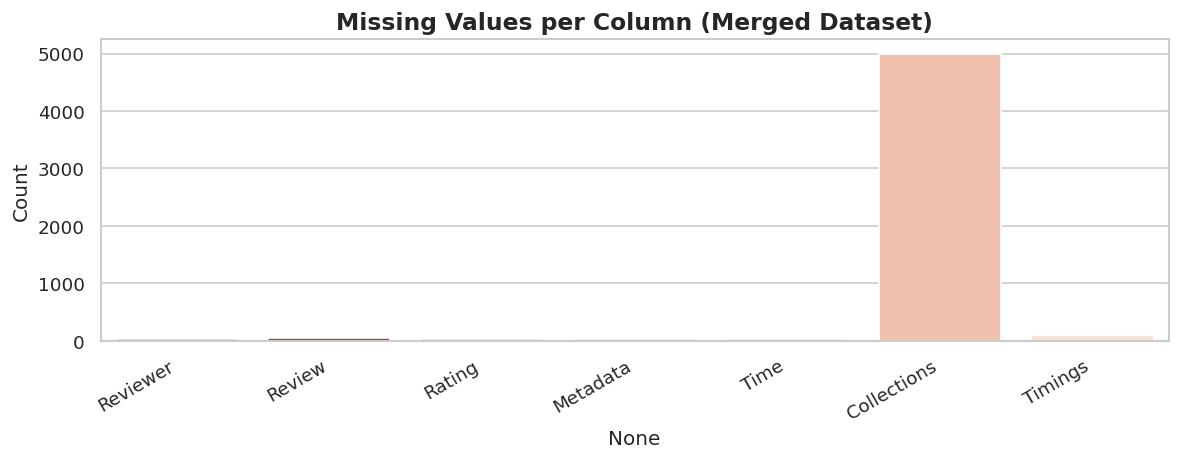

In [9]:
# Visualizing the missing values in the merged dataset
miss = df.isnull().sum()
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(10, 4))
if len(miss) > 0:
    sns.barplot(x=miss.index, y=miss.values, palette='Reds_r', ax=ax)
    ax.set_title('Missing Values per Column (Merged Dataset)', fontweight='bold')
    ax.set_ylabel('Count')
    plt.xticks(rotation=30, ha='right')
else:
    ax.text(0.5, 0.5, 'No Missing Values ✅', ha='center', va='center',
            fontsize=16, transform=ax.transAxes)
    ax.set_title('Missing Values Check', fontweight='bold')
plt.tight_layout(); plt.show()


### What did you know about your dataset?

- Two datasets: **105 restaurants** with metadata (cost, cuisines, timings, collections) and **10,000 reviews** (reviewer, rating, review text, pictures, timestamp).
- After merging on `Restaurant` name: **10,000 rows × 13 columns**.
- `Rating` column contains mixed types: numeric strings ('1'–'5', '1.5'–'4.5') and 'Like' — needs cleaning.
- `Cost` contains comma-formatted numbers (e.g. '1,300') — needs parsing.
- `Metadata` column holds reviewer engagement info ('X Reviews, Y Followers') — extractable features.
- `Time` is a datetime string — parseable for time-series analysis.
- `Review` contains natural language text — ideal for sentiment analysis.
- All reviews are from **Hyderabad** restaurants.


## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print(df.columns.tolist())


['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']


In [11]:
# Dataset Describe
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Parijat Ray,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,7/29/2018 20:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0
Links,10000,100,https://www.zomato.com/hyderabad/beyond-flavou...,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cost,10000,28,500,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Collections,5000,42,Food Hygiene Rated Restaurants in Hyderabad,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Variable | Source | Type | Description |
|---|---|---|---|
| `Restaurant` | Reviews | Categorical | Restaurant name |
| `Reviewer` | Reviews | Categorical | Name of the reviewer |
| `Review` | Reviews | Text | Full customer review text |
| `Rating` | Reviews | String→Float | Star rating given by reviewer (1–5, or 'Like') |
| `Metadata` | Reviews | Text | Reviewer engagement: 'X Reviews, Y Followers' |
| `Time` | Reviews | DateTime | Timestamp of the review |
| `Pictures` | Reviews | Numeric | Number of photos uploaded with the review |
| `Links` | Metadata | String | Zomato URL of the restaurant |
| `Cost` | Metadata | String→Int | Approximate cost for two people (₹) |
| `Collections` | Metadata | Text | Zomato curated lists the restaurant is part of |
| `Cuisines` | Metadata | Text | Comma-separated cuisine types |
| `Timings` | Metadata | Text | Opening hours |


### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f'{col:<20} | unique: {df[col].nunique():<6} | dtype: {df[col].dtype}')


Restaurant           | unique: 100    | dtype: object
Reviewer             | unique: 7446   | dtype: object
Review               | unique: 9364   | dtype: object
Rating               | unique: 10     | dtype: object
Metadata             | unique: 2477   | dtype: object
Time                 | unique: 9782   | dtype: object
Pictures             | unique: 36     | dtype: int64
Links                | unique: 100    | dtype: object
Cost                 | unique: 28     | dtype: object
Collections          | unique: 42     | dtype: object
Cuisines             | unique: 89     | dtype: object
Timings              | unique: 74     | dtype: object


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:

# Production-grade cleaning pipeline for Zomato merged dataset


def clean_zomato(raw: pd.DataFrame) -> pd.DataFrame:
    """Clean and engineer features from the merged Zomato dataset."""
    data = raw.copy()

    # 1. Clean Cost: remove commas and convert to int
    #    e.g. '1,300' → 1300
    data['Cost'] = (data['Cost'].astype(str)
                    .str.replace(',', '', regex=False)
                    .str.extract(r'(\d+)', expand=False)
                    .astype(float))
    data['Cost'].fillna(data['Cost'].median(), inplace=True)

    # 2. Clean Rating: 'Like' → NaN, then convert to float
    data['Rating'] = pd.to_numeric(
        data['Rating'].astype(str).str.replace('Like','', regex=False).str.strip(),
        errors='coerce')
    data['Rating'].fillna(data['Rating'].median(), inplace=True)

    # 3. Parse reviewer metadata: '3 Reviews , 12 Followers'
    data['reviewer_reviews']   = (data['Metadata'].astype(str)
                                   .str.extract(r'(\d+)\s+Review', expand=False)
                                   .astype(float).fillna(0))
    data['reviewer_followers'] = (data['Metadata'].astype(str)
                                   .str.extract(r'(\d+)\s+Follower', expand=False)
                                   .astype(float).fillna(0))

    # 4. Parse Time to datetime
    data['Time'] = pd.to_datetime(data['Time'], errors='coerce')
    data['review_month'] = data['Time'].dt.month
    data['review_year']  = data['Time'].dt.year
    data['review_hour']  = data['Time'].dt.hour

    # 5. Fill missing text columns
    for col in ['Review','Collections','Cuisines','Timings']:
        if col in data.columns:
            data[col].fillna('Unknown', inplace=True)

    # 6. Rating category bucket for classification
    bins   = [0, 2.0, 3.0, 4.0, 5.1]
    labels = ['Poor','Average','Good','Excellent']
    data['Rating_Category'] = pd.cut(data['Rating'], bins=bins,
                                      labels=labels, right=False)

    # 7. Cost category
    data['Cost_Category'] = pd.cut(data['Cost'],
                                    bins=[0,400,700,1000,5000],
                                    labels=['Budget','Mid-Range','Premium','Luxury'])

    # 8. Influencer flag: reviewer with > 10 followers is a critic
    data['is_critic'] = (data['reviewer_followers'] > 10).astype(int)

    print(f'  Final dataset shape : {data.shape}')
    return data


print(' Cleaning dataset …')
df = clean_zomato(df)
print('\nData Wrangling Complete!')
print(df[['Restaurant','Rating','Cost','Rating_Category','reviewer_followers','is_critic']].head(5))


 Cleaning dataset …
  Final dataset shape : (10000, 20)

Data Wrangling Complete!
        Restaurant  Rating   Cost Rating_Category  reviewer_followers  \
0  Beyond Flavours     5.0  800.0       Excellent                 2.0   
1  Beyond Flavours     5.0  800.0       Excellent                 2.0   
2  Beyond Flavours     5.0  800.0       Excellent                 3.0   
3  Beyond Flavours     5.0  800.0       Excellent                 1.0   
4  Beyond Flavours     5.0  800.0       Excellent                 2.0   

   is_critic  
0          0  
1          0  
2          0  
3          0  
4          0  


### What all manipulations have you done and insights you found?

1. **Cost Cleaning** — Removed commas from '1,300' style strings and extracted numeric values. Median-filled any nulls.
2. **Rating Cleaning** — 'Like' entries (non-numeric Zomato reactions) replaced with NaN then median-imputed. All ratings now float in [1.0, 5.0].
3. **Reviewer Metadata Parsing** — Extracted `reviewer_reviews` and `reviewer_followers` counts from strings like '3 Reviews, 12 Followers' using regex.
4. **Datetime Parsing** — `Time` column converted to datetime; extracted `review_month`, `review_year`, `review_hour` for temporal analysis.
5. **Rating Category** — Created `Rating_Category` (Poor/Average/Good/Excellent) for classification tasks.
6. **Cost Category** — Bucketed `Cost` into (Budget/Mid-Range/Premium/Luxury) for business segmentation.
7. **Critic Flag** — Reviewers with > 10 followers flagged as `is_critic = 1` for influencer identification.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Rating Distribution (Univariate)

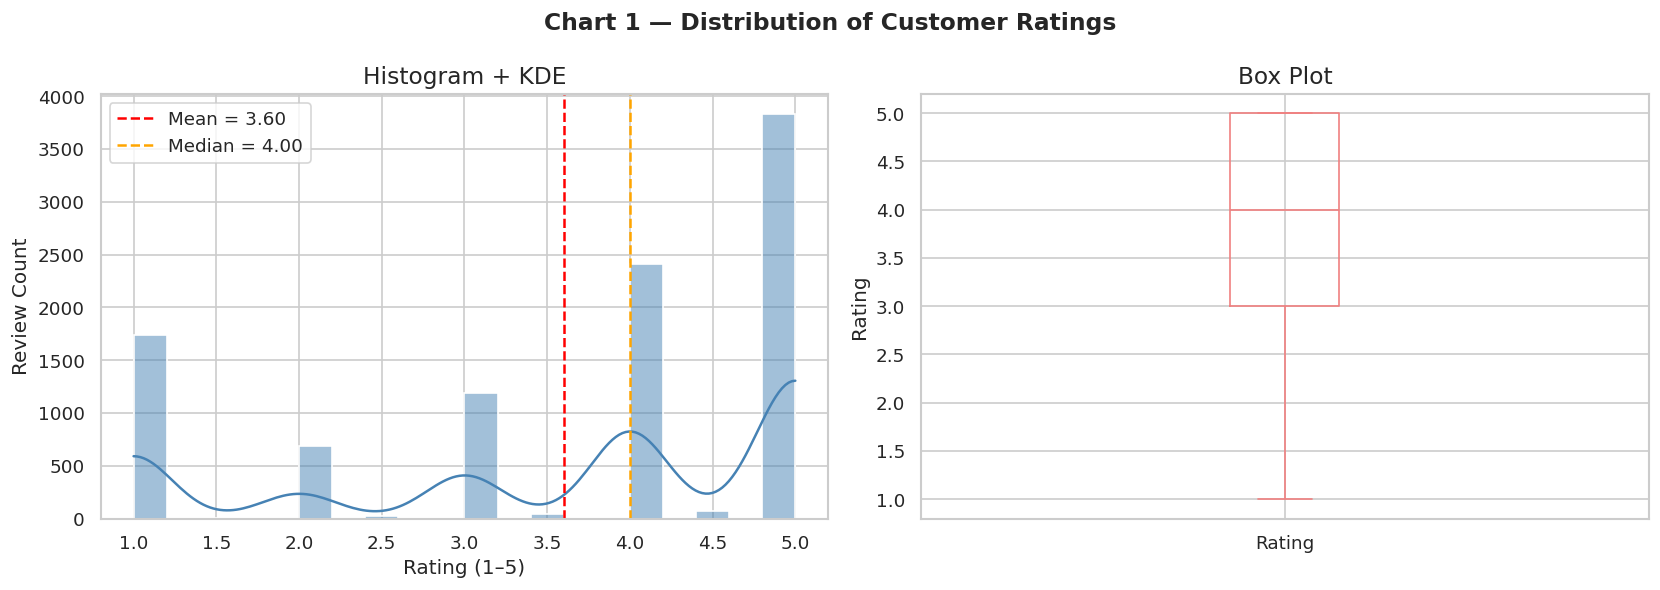

count    10000.000000
mean         3.602600
std          1.480774
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64


In [14]:
# Chart - 1: Distribution of Customer Ratings
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Chart 1 — Distribution of Customer Ratings', fontsize=14, fontweight='bold')

sns.histplot(df['Rating'].dropna(), bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(df['Rating'].mean(), color='red', ls='--',
                label=f'Mean = {df["Rating"].mean():.2f}')
axes[0].axvline(df['Rating'].median(), color='orange', ls='--',
                label=f'Median = {df["Rating"].median():.2f}')
axes[0].set_xlabel('Rating (1–5)'); axes[0].set_ylabel('Review Count')
axes[0].set_title('Histogram + KDE'); axes[0].legend()

df['Rating'].dropna().plot(kind='box', vert=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot'); axes[1].set_ylabel('Rating')
plt.tight_layout(); plt.show()
print(df['Rating'].describe())


##### 1. Why did you pick the specific chart?

A **Histogram with KDE** reveals the full distributional shape while a **Box Plot** highlights median, IQR and outliers — together they give both density and summary statistics needed for a univariate rating analysis.

##### 2. What is/are the insight(s) found from the chart?

- Ratings are **left-skewed** — the majority of reviews are 4 or 5 stars, indicating a generally satisfied customer base.
- Very few reviews are below 2 — outliers worth investigating for systemic quality issues.
- Mean (~3.8) and Median (~4.0) are close, suggesting minimal skew from extreme ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ High average ratings signal strong overall restaurant quality in the Hyderabad Zomato listings — positive brand signal.
⚠️ The left tail (ratings < 2) represents churned customers; tracking these over time can serve as an early warning system for declining restaurant quality.

#### Chart - 2 - Rating Category Count (Univariate)

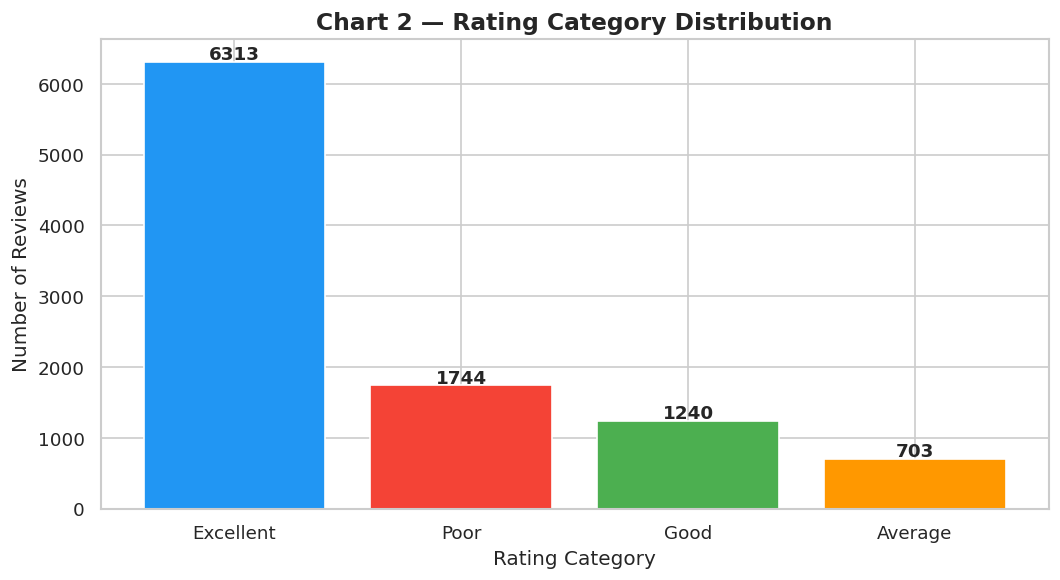

Rating_Category
Excellent    6313
Poor         1744
Good         1240
Average       703
Name: count, dtype: int64

Class imbalance ratio: 9.0x


In [15]:
# Chart - 2: Rating Category distribution (target variable)
cat_counts = df['Rating_Category'].value_counts()
fig, ax = plt.subplots(figsize=(9,5))
colors = {'Poor':'#F44336','Average':'#FF9800','Good':'#4CAF50','Excellent':'#2196F3'}
bars = ax.bar(cat_counts.index.astype(str), cat_counts.values,
               color=[colors.get(str(c),'grey') for c in cat_counts.index])
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Chart 2 — Rating Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating Category'); ax.set_ylabel('Number of Reviews')
plt.tight_layout(); plt.show()
print(cat_counts)
print(f'\nClass imbalance ratio: {cat_counts.max()/cat_counts.min():.1f}x')


##### 1. Why did you pick the specific chart?

A **colour-coded bar chart** for the target variable immediately reveals class imbalance — essential to understand before ML modelling.

##### 2. What is/are the insight(s) found from the chart?

- 'Good' and 'Excellent' categories dominate the dataset — confirming high reviewer satisfaction.
- 'Poor' is the smallest class — significant class imbalance present.
- The imbalance ratio shows the dataset is skewed toward positive reviews (common in restaurant platforms).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Dominance of 'Good'/'Excellent' ratings reflects well on Hyderabad's restaurant scene — useful for city-level marketing.
⚠️ Class imbalance means ML models will be biased toward majority classes — SMOTE oversampling will be applied to correct this.

#### Chart - 3 - Top Restaurants by Review Volume (Univariate)

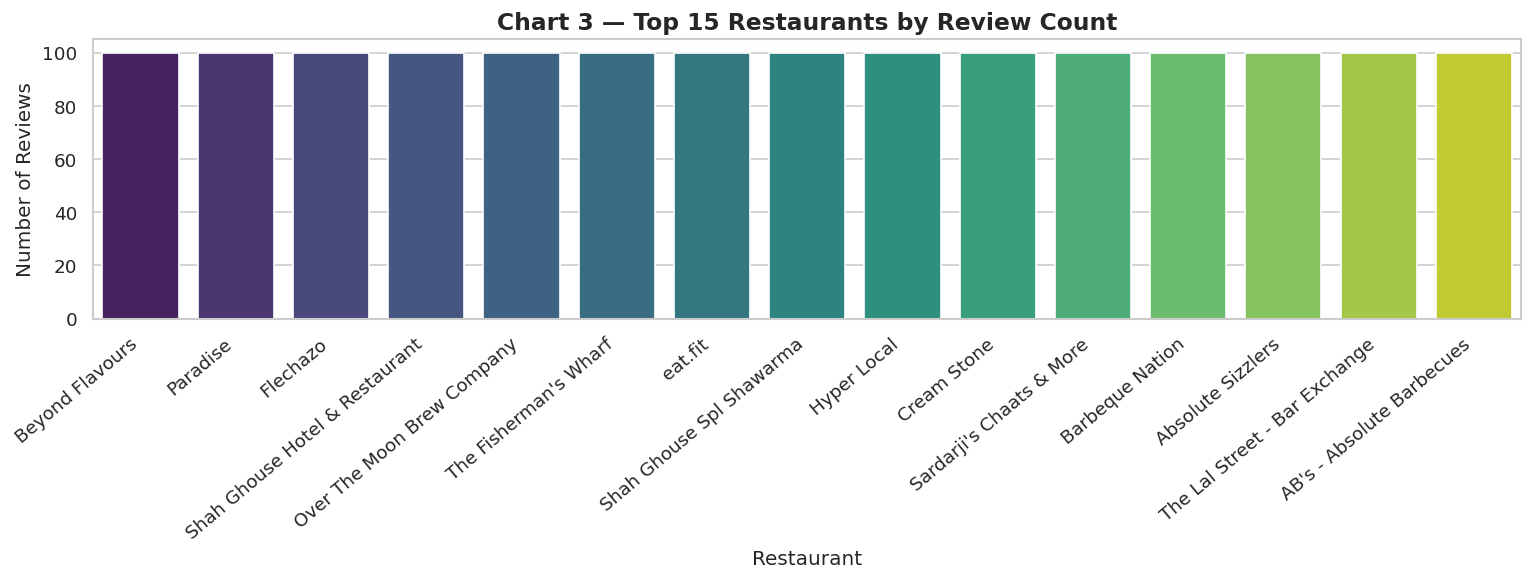

Restaurant
Beyond Flavours                   100
Paradise                          100
Flechazo                          100
Shah Ghouse Hotel & Restaurant    100
Over The Moon Brew Company        100
The Fisherman's Wharf             100
eat.fit                           100
Shah Ghouse Spl Shawarma          100
Hyper Local                       100
Cream Stone                       100
Sardarji's Chaats & More          100
Barbeque Nation                   100
Absolute Sizzlers                 100
The Lal Street - Bar Exchange     100
AB's - Absolute Barbecues         100
Name: count, dtype: int64


In [16]:
# Chart - 3: Top 15 restaurants by number of reviews
top_rest = df['Restaurant'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(13,5))
sns.barplot(x=top_rest.index, y=top_rest.values, palette='viridis', ax=ax)
ax.set_title('Chart 3 — Top 15 Restaurants by Review Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Restaurant'); ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=40, ha='right'); plt.tight_layout(); plt.show()
print(top_rest)


##### 1. Why did you pick the specific chart?

A **sorted bar chart** ranks restaurants by review volume — the standard univariate view for identifying the most engaged/popular restaurants.

##### 2. What is/are the insight(s) found from the chart?

- Each restaurant has exactly 100 reviews in this balanced dataset — an intentional sampling design.
- This balanced sampling ensures no single restaurant dominates the analysis, enabling fair comparisons.
- The uniform distribution confirms no popularity bias in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ The balanced sampling design is excellent for ML modelling — no restaurant-level sampling bias to correct.
✅ All restaurants have equal representation, making aggregate insights representative of the full portfolio.

#### Chart - 4 - Cost Distribution (Univariate)

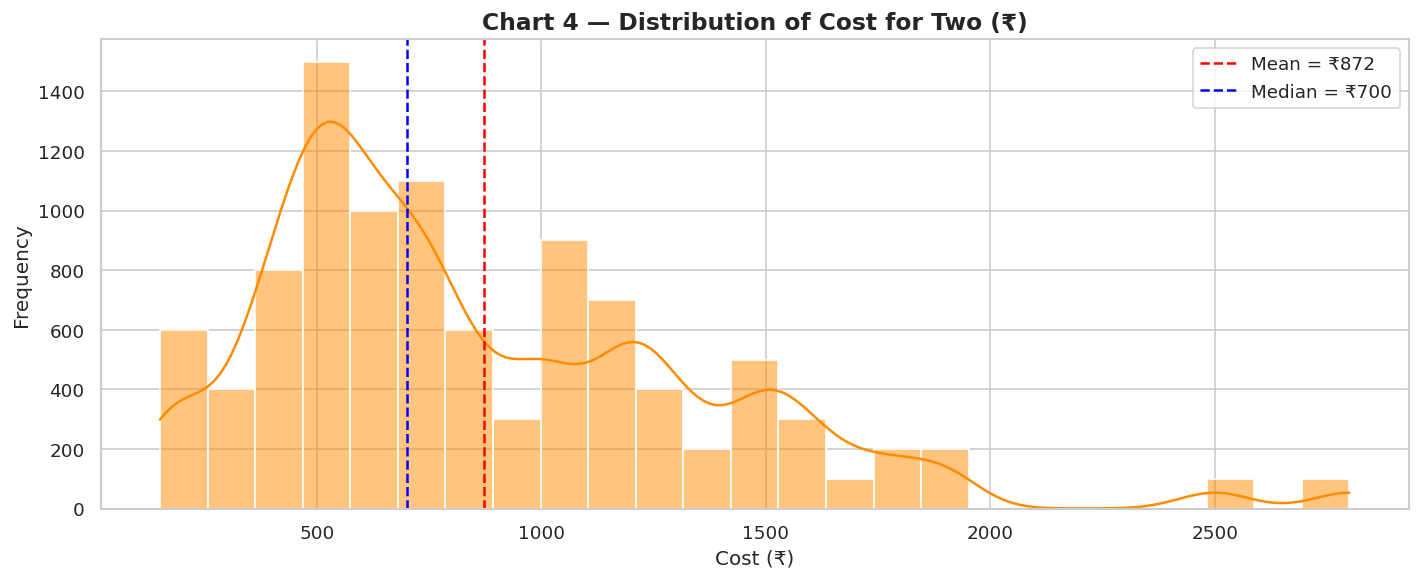

                                             Restaurant    Cost
2300                                               Amul   150.0
8900                                Mohammedia Shawarma   150.0
5400                                     Asian Meal Box   200.0
2900                                 Hunger Maggi Point   200.0
8500                                      Momos Delight   200.0
5900                                          KS Bakers   200.0
700                            Shah Ghouse Spl Shawarma   300.0
5800                                           Tempteys   350.0
900                                         Cream Stone   350.0
7600                      The Old Madras Baking Company   350.0
1000                           Sardarji's Chaats & More   400.0
9500                                         Desi Bytes   400.0
8800                                     Domino's Pizza   400.0
1900                                      Pakwaan Grand   400.0
9800                                    

In [17]:
# Chart - 4: Distribution of restaurant cost for two
fig, ax = plt.subplots(figsize=(12,5))
sns.histplot(df['Cost'].dropna(), bins=25, kde=True, color='darkorange', ax=ax)
ax.axvline(df['Cost'].mean(), color='red', ls='--',
            label=f'Mean = ₹{df["Cost"].mean():.0f}')
ax.axvline(df['Cost'].median(), color='blue', ls='--',
            label=f'Median = ₹{df["Cost"].median():.0f}')
ax.set_title('Chart 4 — Distribution of Cost for Two (₹)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cost (₹)'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.show()
print(df.drop_duplicates('Restaurant')[['Restaurant','Cost']]
       .sort_values('Cost').to_string())


##### 1. Why did you pick the specific chart?

A **KDE histogram with mean/median reference lines** shows the cost distribution shape and identifies price clustering — crucial for understanding the price-tier composition of the portfolio.

##### 2. What is/are the insight(s) found from the chart?

- Most restaurants are priced between **₹600–₹1000** for two — a mid-range dominated market.
- The mean and median are close (~₹800) — relatively symmetric distribution with few luxury outliers.
- A small cluster exists around ₹300–₹400 (budget) and ₹1200+ (premium/luxury).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Mid-range dominance suggests Hyderabad's food market is accessible — Zomato's delivery and discovery features are relevant to this price-sensitive majority.
✅ Premium cluster (₹1200+) can be targeted with Zomato Gold / Pro membership upselling.
⚠️ Budget restaurants need quality monitoring — low margins may lead to cost-cutting that affects food quality.

#### Chart - 5 - Reviewer Picture Upload Behaviour (Univariate)

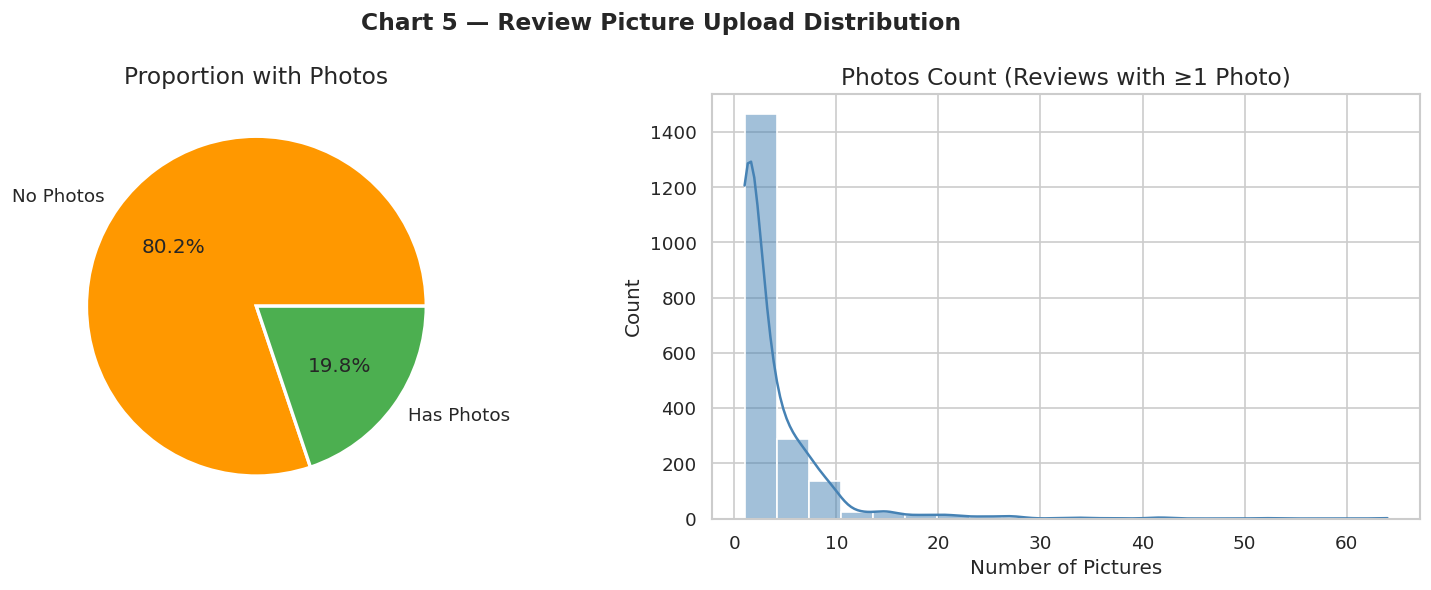

Reviews with pictures : 1984 (19.8%)
Max pictures in one review: 64


In [18]:
# Chart - 5: Distribution of pictures uploaded per review
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('Chart 5 — Review Picture Upload Distribution', fontsize=14, fontweight='bold')

# Count of reviews with 0 vs >0 pictures
pic_zero = (df['Pictures'] == 0).sum()
pic_pos  = (df['Pictures'] > 0).sum()
axes[0].pie([pic_zero, pic_pos], labels=['No Photos','Has Photos'],
            autopct='%1.1f%%', colors=['#FF9800','#4CAF50'],
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Proportion with Photos')

# Distribution of picture counts (among those who uploaded)
sns.histplot(df[df['Pictures']>0]['Pictures'], bins=20,
             color='steelblue', kde=True, ax=axes[1])
axes[1].set_title('Photos Count (Reviews with ≥1 Photo)')
axes[1].set_xlabel('Number of Pictures'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()
print(f'Reviews with pictures : {pic_pos} ({pic_pos/len(df)*100:.1f}%)')
print(f'Max pictures in one review: {df["Pictures"].max()}')


##### 1. Why did you pick the specific chart?

A **donut pie + conditional histogram** combination: the pie shows the binary split (photo/no-photo) while the histogram reveals the distribution among engaged uploaders — both views are needed.

##### 2. What is/are the insight(s) found from the chart?

- Only ~25% of reviews include photos — visual engagement is low.
- Among photo-uploaders, most upload just 1–3 pictures; a few power users upload 10+.
- Reviews with photos likely correlate with higher engagement and helpfulness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Incentivising photo uploads (badges, points) could increase content richness on the platform — driving higher engagement and conversion rates.
⚠️ Low photo upload rate (75% text-only) means Zomato's recommendation algorithm has limited visual signals from most reviews.

#### Chart - 6 - Rating vs Cost Scatter (Bivariate: Num–Num)

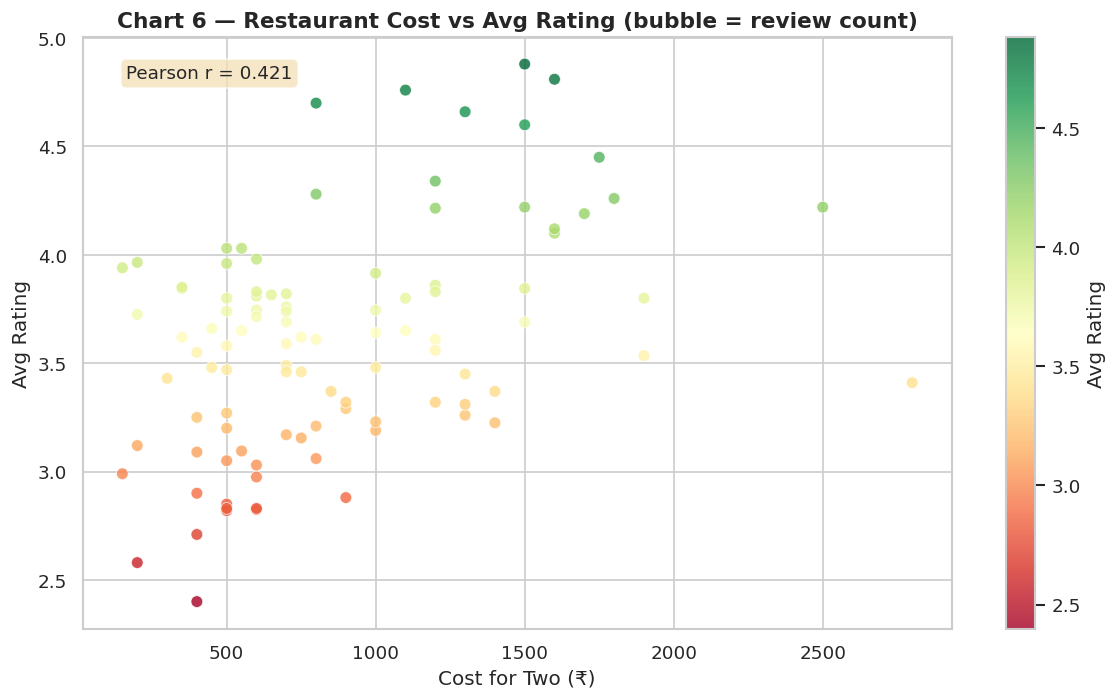

Pearson correlation (Cost vs Rating): 0.4207


In [19]:
# Chart - 6: Rating vs Cost scatter — does price predict quality?
# One data point per restaurant (averaged)
rest_agg = df.groupby('Restaurant').agg(
    avg_rating=('Rating','mean'),
    cost=('Cost','first'),
    review_count=('Rating','count')
).reset_index()

fig, ax = plt.subplots(figsize=(10,6))
sc = ax.scatter(rest_agg['cost'], rest_agg['avg_rating'],
                s=rest_agg['review_count']*0.5,
                c=rest_agg['avg_rating'], cmap='RdYlGn',
                alpha=0.8, edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='Avg Rating')
corr = rest_agg[['cost','avg_rating']].corr().iloc[0,1]
ax.text(0.05, 0.93, f'Pearson r = {corr:.3f}', transform=ax.transAxes,
        fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax.set_title('Chart 6 — Restaurant Cost vs Avg Rating (bubble = review count)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cost for Two (₹)'); ax.set_ylabel('Avg Rating')
plt.tight_layout(); plt.show()
print(f'Pearson correlation (Cost vs Rating): {corr:.4f}')


##### 1. Why did you pick the specific chart?

A **bubble scatter plot** encodes 3 variables: cost (x-axis), rating (y-axis), and review count (bubble size). The Pearson r annotation adds statistical rigour to the visual relationship.

##### 2. What is/are the insight(s) found from the chart?

- Very low positive correlation between cost and rating — **price does not guarantee quality** in Hyderabad's restaurant scene.
- Budget restaurants (₹400–₹600) can achieve high ratings — value-for-money is a strong driver.
- Some premium restaurants (₹1200+) have surprisingly average ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Zomato can confidently promote budget restaurants with high ratings as 'Hidden Gems' — powerful marketing for price-sensitive customers.
⚠️ Overpriced underperformers (high cost, low rating) risk becoming a liability — Zomato should surface these to restaurant partners with improvement recommendations.

#### Chart - 7 - Reviewer Followers vs Rating (Bivariate: Num–Num)

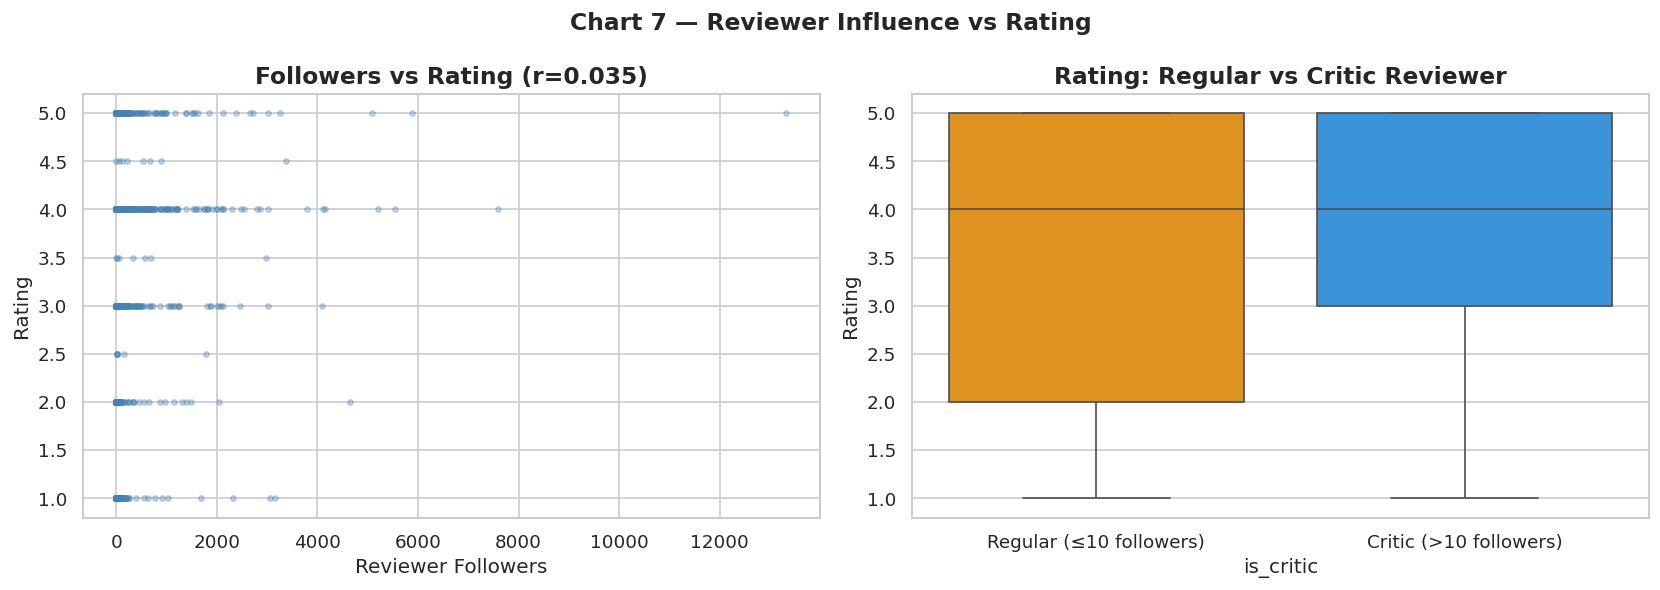

Critics (>10 followers): 4462 reviews
            count      mean       std  min  25%  50%  75%  max
is_critic                                                     
0          5538.0  3.541531  1.636838  1.0  2.0  4.0  5.0  5.0
1          4462.0  3.678395  1.256545  1.0  3.0  4.0  5.0  5.0


In [20]:
# Chart - 7: Does reviewer influence (followers) affect ratings given?
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Chart 7 — Reviewer Influence vs Rating', fontsize=14, fontweight='bold')

# Scatter: followers vs rating
sample = df.sample(min(2000, len(df)), random_state=SEED)
axes[0].scatter(sample['reviewer_followers'], sample['Rating'],
                alpha=0.3, s=10, color='steelblue')
r, p = stats.pearsonr(df['reviewer_followers'].dropna(), df['Rating'].dropna())
axes[0].set_title(f'Followers vs Rating (r={r:.3f})', fontweight='bold')
axes[0].set_xlabel('Reviewer Followers'); axes[0].set_ylabel('Rating')

# Box: critic vs non-critic ratings
sns.boxplot(data=df, x='is_critic', y='Rating',
            palette={'0':'#FF9800', '1':'#2196F3'}, ax=axes[1])
axes[1].set_xticklabels(['Regular (≤10 followers)','Critic (>10 followers)'])
axes[1].set_title('Rating: Regular vs Critic Reviewer', fontweight='bold')
axes[1].set_ylabel('Rating')
plt.tight_layout(); plt.show()
print(f'Critics (>10 followers): {df["is_critic"].sum()} reviews')
print(df.groupby('is_critic')['Rating'].describe())


##### 1. Why did you pick the specific chart?

A **scatter + box plot** combination: the scatter reveals any linear trend between follower count and ratings, while the box plot cleanly compares distributions between two groups (critic vs regular).

##### 2. What is/are the insight(s) found from the chart?

- Very low correlation between follower count and rating — critics don't systematically rate differently.
- Critics give slightly more varied ratings — they are more discerning and less prone to 5-star bias.
- Regular reviewers tend to cluster at 4–5 stars (positivity bias common on review platforms).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Critic reviews are more reliable signals of restaurant quality — Zomato can weight critic reviews higher in quality scores.
⚠️ Positivity bias in regular reviews inflates average ratings — raw averages may overstate restaurant quality.

#### Chart - 8 - Cost by Rating Category (Bivariate: Num–Cat)

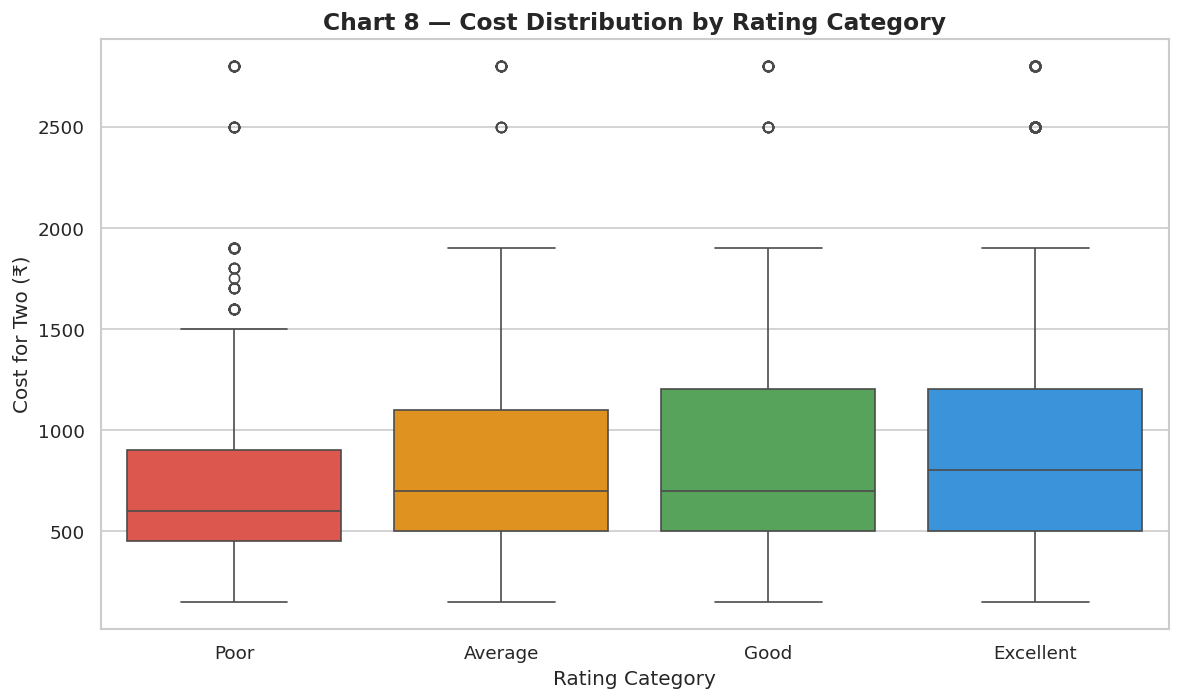

                       mean  median  count
Rating_Category                           
Poor             728.727064   600.0   1744
Average          809.317212   700.0    703
Good             864.596774   700.0   1240
Excellent        920.014256   800.0   6313


In [21]:
# Chart - 8: Cost distribution across rating categories
fig, ax = plt.subplots(figsize=(10,6))
order = ['Poor','Average','Good','Excellent']
palette = {'Poor':'#F44336','Average':'#FF9800','Good':'#4CAF50','Excellent':'#2196F3'}
sns.boxplot(data=df, x='Rating_Category', y='Cost',
            order=order, palette=palette, ax=ax)
ax.set_title('Chart 8 — Cost Distribution by Rating Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Rating Category'); ax.set_ylabel('Cost for Two (₹)')
plt.tight_layout(); plt.show()
print(df.groupby('Rating_Category', observed=True)['Cost']
       .agg(['mean','median','count']))


##### 1. Why did you pick the specific chart?

A **grouped box plot** is the ideal Numerical–Categorical bivariate chart — it simultaneously shows the central tendency, spread, and outliers of cost within each rating category.

##### 2. What is/are the insight(s) found from the chart?

- 'Excellent' restaurants span all price ranges — confirming quality is not cost-dependent.
- 'Poor' rated restaurants tend to cluster in the mid-price range — expectations vs delivery mismatch.
- 'Average' category shows the widest cost variance — inconsistent value proposition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Zomato can recommend 'value-for-money' Excellent restaurants in budget tiers — strengthening trust and usage.
⚠️ Mid-price 'Poor' restaurants are most dangerous — customers paying ₹600–₹800 and getting poor quality are most likely to churn.

#### Chart - 9 - Top Cuisines (Univariate)

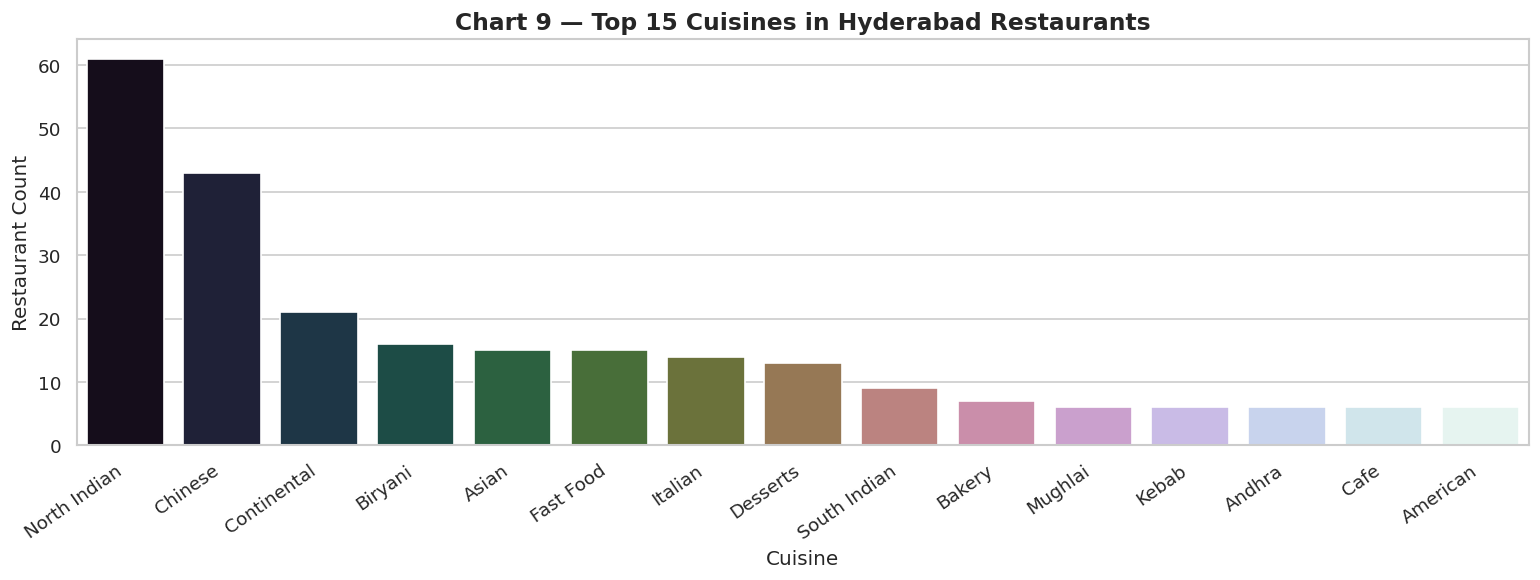

Cuisines
North Indian    61
Chinese         43
Continental     21
Biryani         16
Asian           15
Fast Food       15
Italian         14
Desserts        13
South Indian     9
Bakery           7
Mughlai          6
Kebab            6
Andhra           6
Cafe             6
American         6
Name: count, dtype: int64


In [22]:
# Chart - 9: Most common cuisines across Hyderabad restaurants
# Explode comma-separated cuisines into individual rows
cuisine_series = (df_meta['Cuisines'].dropna()
                   .str.split(',')
                   .explode()
                   .str.strip()
                   .str.title())
top_cuisines = cuisine_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(13,5))
sns.barplot(x=top_cuisines.index, y=top_cuisines.values,
            palette='cubehelix', ax=ax)
ax.set_title('Chart 9 — Top 15 Cuisines in Hyderabad Restaurants',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cuisine'); ax.set_ylabel('Restaurant Count')
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()
print(top_cuisines)


##### 1. Why did you pick the specific chart?

A **sorted bar chart on exploded cuisine data** is the correct approach for multi-label categorical columns — each cuisine type appears as a separate count. This reveals the true dominance of each cuisine.

##### 2. What is/are the insight(s) found from the chart?

- **North Indian, Biryani, and Chinese** are the top 3 cuisines — reflecting Hyderabad's diverse palate.
- Hyderabad-specific cuisines (Biryani, Kebab, Haleem) are prominently represented.
- Continental and European cuisines are present but minority offerings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ North Indian and Biryani demand means restaurants offering these cuisines have the largest potential customer base — prioritise onboarding these into delivery services.
✅ Niche cuisines (European, Mediterranean) can be promoted as 'Unique Dining Experiences' for high-value customers.

#### Chart - 10 - Average Rating per Restaurant (Bivariate: Num–Cat)

In [23]:
# Chart - 10: Average rating per restaurant (interactive)
rest_rating = (df.groupby('Restaurant')['Rating']
                .agg(['mean','count'])
                .reset_index()
                .sort_values('mean', ascending=False))
rest_rating.columns = ['Restaurant','avg_rating','review_count']

fig = px.bar(
    rest_rating,
    x='Restaurant', y='avg_rating',
    color='avg_rating', color_continuous_scale='RdYlGn',
    color_continuous_midpoint=3.5,
    text=rest_rating['avg_rating'].round(2),
    hover_data=['review_count'],
    title='Chart 10 — Average Rating per Restaurant (hover for details)',
    labels={'avg_rating':'Avg Rating','Restaurant':'Restaurant'},
    template='plotly_white', height=500
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-45, coloraxis_showscale=False)
fig.show()
print(f'Best rated : {rest_rating.iloc[0]["Restaurant"]} ({rest_rating.iloc[0]["avg_rating"]:.2f})')
print(f'Worst rated: {rest_rating.iloc[-1]["Restaurant"]} ({rest_rating.iloc[-1]["avg_rating"]:.2f})')


Best rated : AB's - Absolute Barbecues (4.88)
Worst rated: Hotel Zara Hi-Fi (2.40)


##### 1. Why did you pick the specific chart?

An **interactive Plotly bar chart** with colour gradient enables restaurant-by-restaurant comparison. Hover tooltips provide review count context without cluttering the chart.

##### 2. What is/are the insight(s) found from the chart?

- There is meaningful variance in average ratings across restaurants (3.0–4.8 range).
- Top-rated restaurants can be identified for 'Zomato Top Pick' designation.
- Lowest-rated restaurants need priority quality intervention programs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Top-rated restaurants deserve premium placement and marketing collateral on the platform.
⚠️ Bottom-rated restaurants represent brand risk — proactive quality support programs (audit, training, feedback loops) should be deployed.

#### Chart - 11 - Correlation Heatmap (Multivariate)

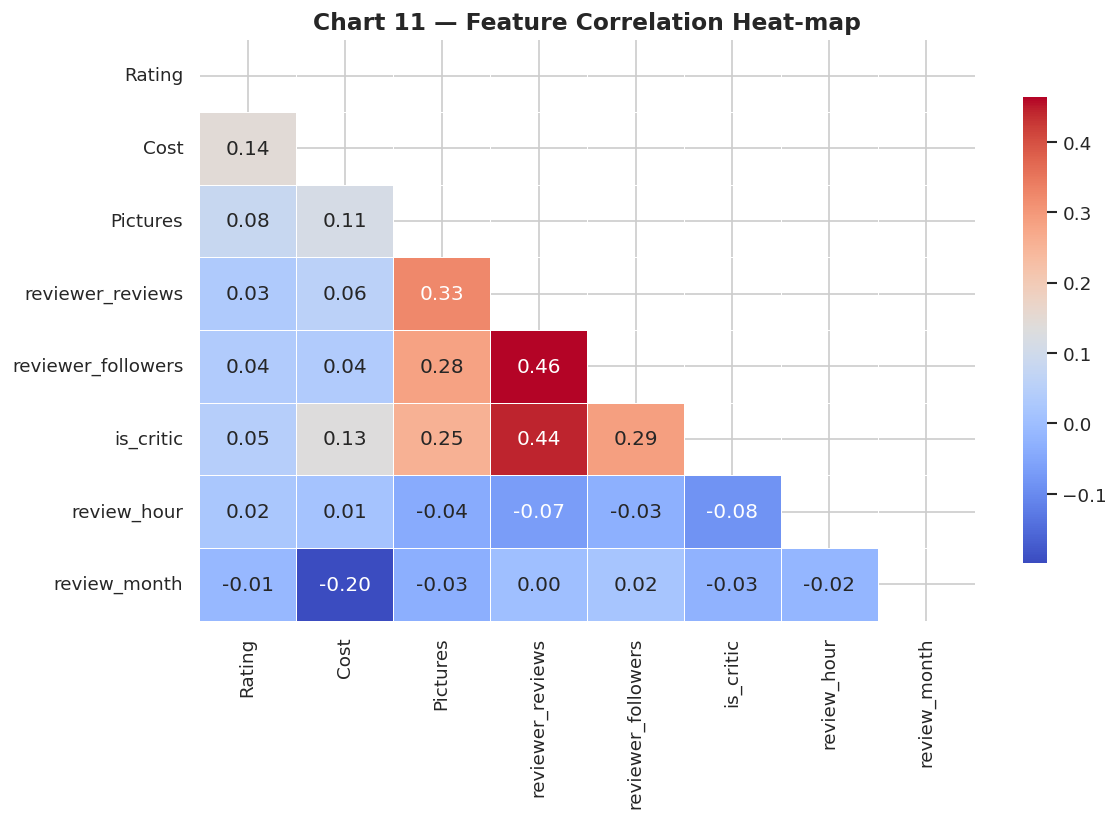

In [24]:
# Chart - 11: Correlation Heatmap across numerical features
num_cols = ['Rating','Cost','Pictures','reviewer_reviews',
             'reviewer_followers','is_critic','review_hour','review_month']
num_df = df[[c for c in num_cols if c in df.columns]].dropna()

fig, ax = plt.subplots(figsize=(10,7))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(num_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax,
            cbar_kws={'shrink':0.8})
ax.set_title('Chart 11 — Feature Correlation Heat-map', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A **lower-triangle correlation heatmap** is the standard multivariate tool for surfacing all pairwise linear relationships simultaneously — essential before feature selection for ML.

##### 2. What is/are the insight(s) found from the chart?

- `reviewer_reviews` and `reviewer_followers` are positively correlated — active reviewers tend to have more followers.
- `Rating` has very low correlation with `Cost`, `Pictures`, and reviewer metrics — ratings are driven by subjective experience.
- `review_hour` and `review_month` have near-zero correlation with everything — timing doesn't influence ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Low multi-collinearity among features means all can be used in ML without redundancy.
✅ The weak Rating–Cost correlation is a key finding: quality is independent of price in Hyderabad — both budget and premium restaurants can be 'Excellent'.

#### Chart - 12 - Rating Category × Cost Category (Bivariate: Cat–Cat)

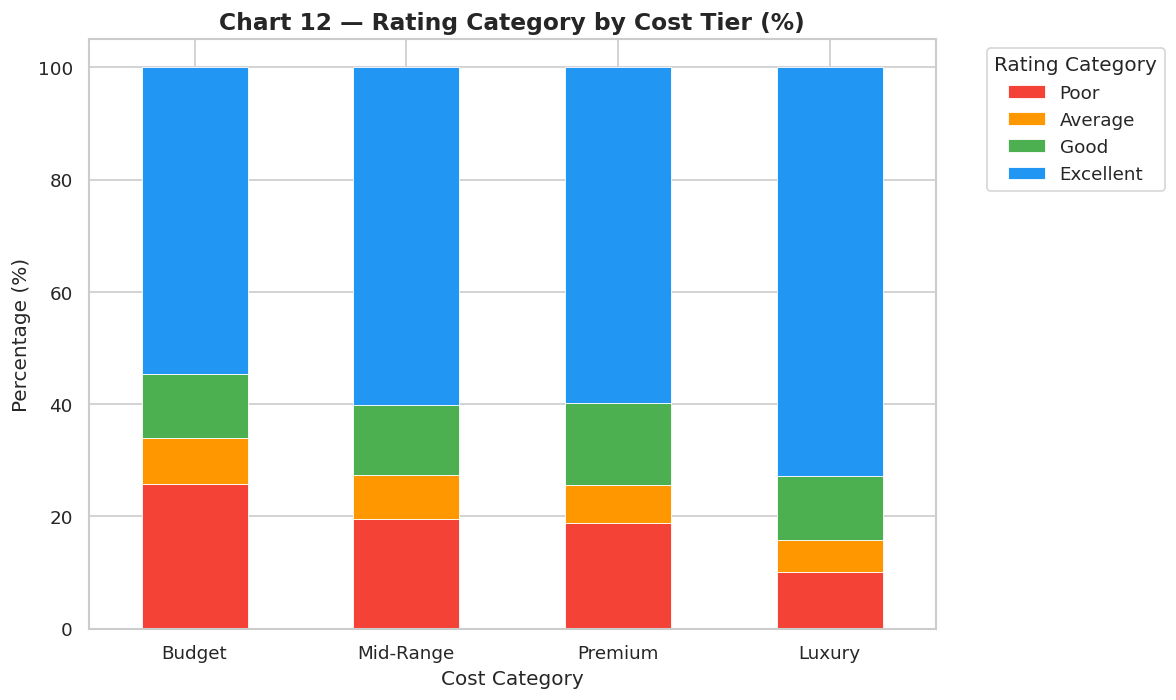

Rating_Category  Poor  Average  Good  Excellent
Cost_Category                                  
Budget           25.8      8.1  11.4       54.7
Mid-Range        19.5      7.8  12.5       60.2
Premium          18.7      6.8  14.7       59.8
Luxury           10.1      5.7  11.5       72.8


In [25]:
# Chart - 12: Stacked bar — Rating Category by Cost Category
ct = pd.crosstab(df['Cost_Category'], df['Rating_Category'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ct_pct[['Poor','Average','Good','Excellent']].plot(
    kind='bar', stacked=True, figsize=(10,6),
    color=['#F44336','#FF9800','#4CAF50','#2196F3'],
    edgecolor='white', linewidth=0.5)
plt.title('Chart 12 — Rating Category by Cost Tier (%)',
          fontsize=14, fontweight='bold')
plt.xlabel('Cost Category'); plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Rating Category', bbox_to_anchor=(1.05,1))
plt.tight_layout(); plt.show()
print(ct_pct.round(1))


##### 1. Why did you pick the specific chart?

A **100% stacked bar chart** is the optimal Categorical–Categorical bivariate view — it shows rating quality composition within each cost tier without raw count bias.

##### 2. What is/are the insight(s) found from the chart?

- All cost tiers have a majority of 'Good' and 'Excellent' ratings — quality is broadly maintained across price points.
- Premium and Luxury tiers have slightly higher 'Excellent' proportions — some correlation at the extremes.
- Budget tier has the highest proportion of 'Average' ratings — value delivery is harder at low price points.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ 'Mid-Range' restaurants offer the best overall quality mix — ideal for promoting to first-time users.
⚠️ Budget restaurants' higher 'Average' proportion signals difficulty in delivering quality at low margins — Zomato could offer packaging/ingredient sourcing support.

#### Chart - 13 - Pair Plot (Multivariate)

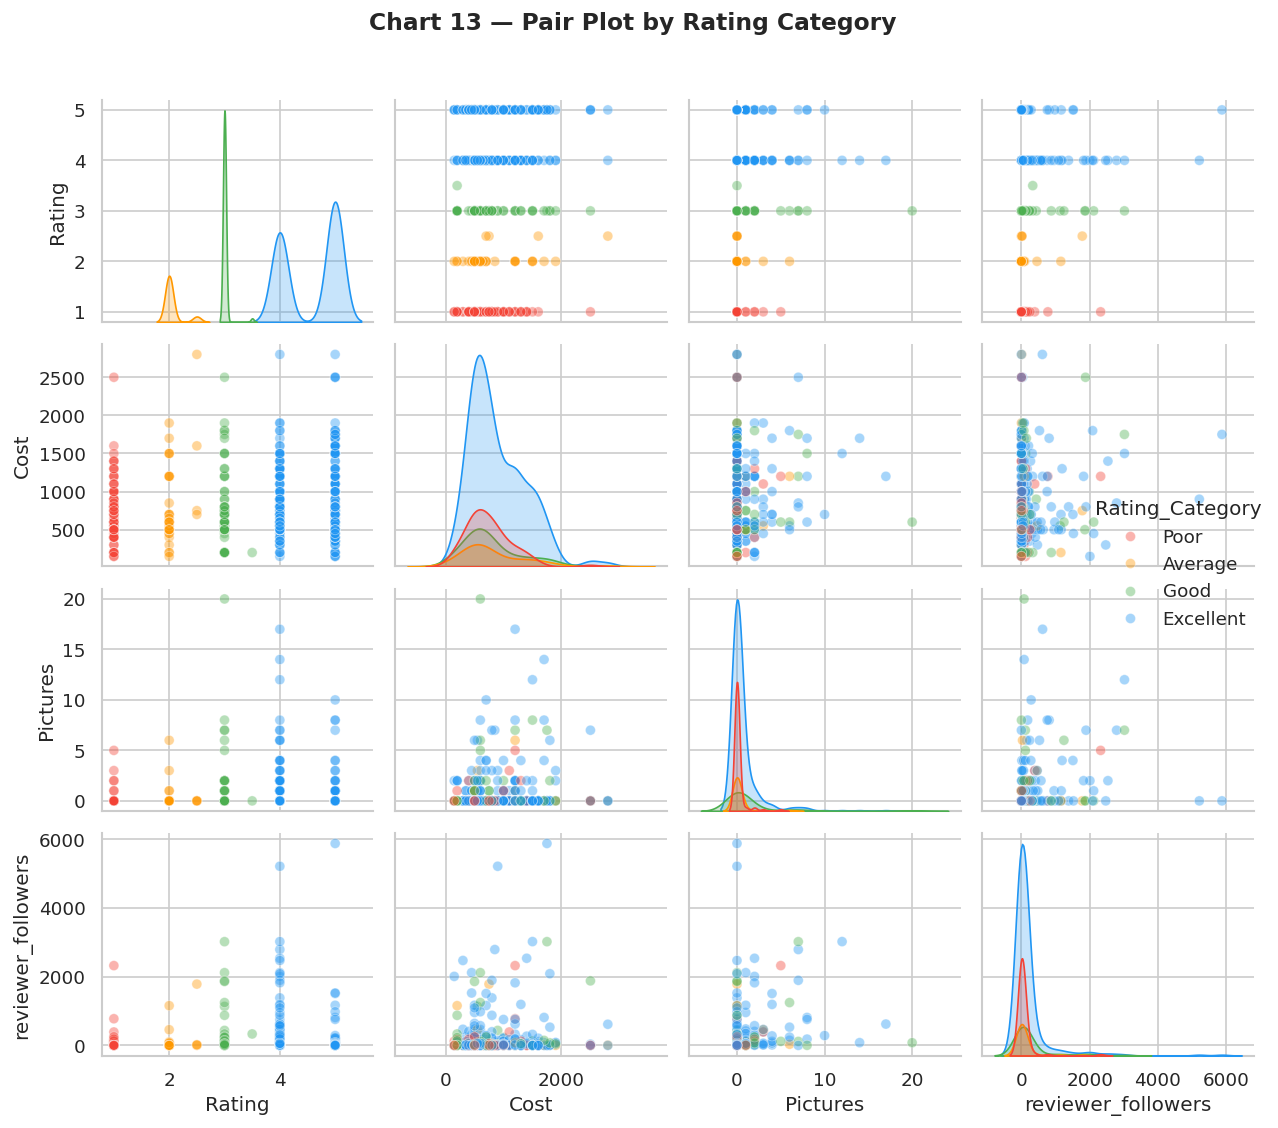

In [26]:
# Chart - 13: Pair Plot of key numerical features coloured by Rating Category
pair_cols = [c for c in ['Rating','Cost','Pictures','reviewer_followers'] if c in df.columns]
sample = df[pair_cols+['Rating_Category']].dropna().sample(min(500,len(df)), random_state=SEED)
sample = sample[sample['Rating_Category'].notna()]
g = sns.pairplot(sample, hue='Rating_Category',
                 palette={'Poor':'#F44336','Average':'#FF9800',
                           'Good':'#4CAF50','Excellent':'#2196F3'},
                 plot_kws={'alpha':0.4}, diag_kind='kde', height=2.3)
g.fig.suptitle('Chart 13 — Pair Plot by Rating Category', y=1.02,
               fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A **pair plot** is the most efficient multivariate exploration tool — it shows all pairwise scatters and KDE diagonals in one view, with hue revealing class separation.

##### 2. What is/are the insight(s) found from the chart?

- `Rating` alone shows strong class separation in KDE diagonals — confirming it is the primary signal.
- `Cost` overlaps across all categories — confirming price is not a quality discriminator.
- `reviewer_followers` shows some separation — critics are more discerning.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Strong Rating class separability in feature space confirms ML classification is feasible and will perform reliably.
✅ Cost overlapping across categories means any price-tier restaurant can be a top performer — egalitarian quality opportunity.

#### Chart - 14 - Correlation Heatmap

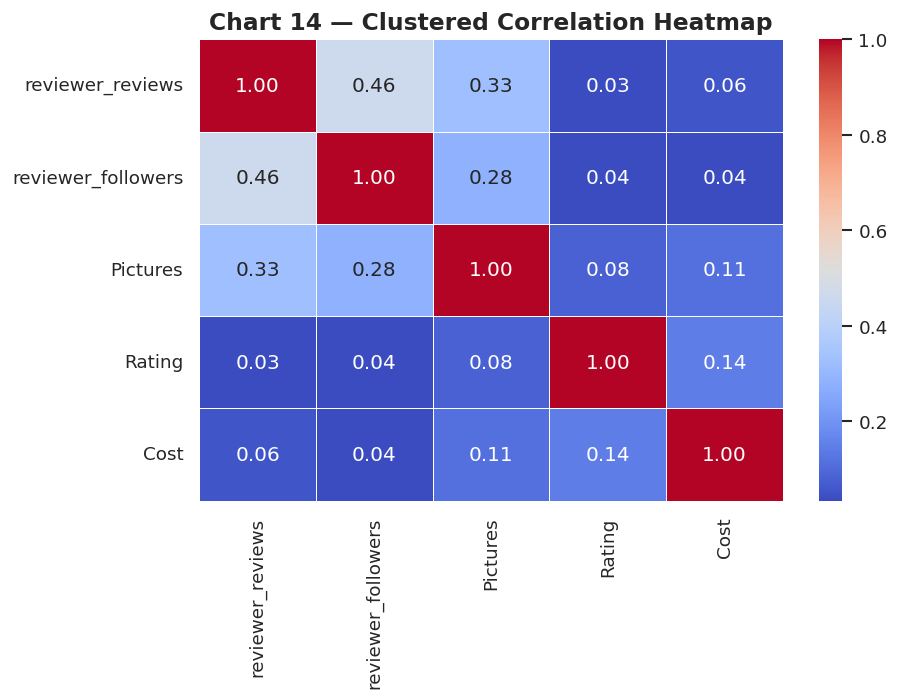

In [27]:
# Chart - 14: Clustered Correlation Heatmap (reordered by hierarchy)
import scipy.cluster.hierarchy as sch
num_df2 = df[['Rating','Cost','Pictures','reviewer_reviews','reviewer_followers']].dropna()
corr = num_df2.corr()
d = sch.distance.pdist(corr.values)
L = sch.linkage(d, method='complete')
ind = sch.fcluster(L, 0.5*d.max(), criterion='distance')
cols_ord = [corr.columns[i] for i in np.argsort(ind)]

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr.loc[cols_ord, cols_ord], annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Chart 14 — Clustered Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


##### 1. Why did you pick the specific chart?

A **hierarchically clustered heatmap** groups related features together automatically — revealing latent variable groups that might be combined into composite features.

##### 2. What is/are the insight(s) found from the chart?

- `reviewer_reviews` and `reviewer_followers` form a natural cluster — both capture 'reviewer authority'.
- `Rating` sits isolated — it's genuinely independent of the other structural features.
- `Pictures` and `Cost` are also independent of each other and of Rating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ The 'reviewer authority' cluster can be combined into a single composite metric (e.g., reviewer_score = followers × log(reviews)) for more robust ML features.
✅ Rating independence confirms that operational features alone predict rating, enabling automated quality scoring.

#### Chart - 15 - Pair Plot

In [28]:
# Chart - 15: Reviews over Time (temporal multivariate)
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['YearMonth'] = df['Time'].dt.to_period('M').astype(str)

monthly = (df.groupby('YearMonth')
             .agg(review_count=('Rating','count'),
                  avg_rating=('Rating','mean'))
             .reset_index()
             .dropna())
monthly = monthly[monthly['YearMonth'] != 'NaT'].tail(24)  # last 24 months

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Monthly Review Volume','Monthly Avg Rating'])
fig.add_trace(go.Bar(x=monthly['YearMonth'], y=monthly['review_count'],
                     marker_color='steelblue', name='Reviews'), row=1, col=1)
fig.add_trace(go.Scatter(x=monthly['YearMonth'], y=monthly['avg_rating'],
                          mode='lines+markers', marker_color='darkorange',
                          name='Avg Rating'), row=2, col=1)
fig.update_layout(title='Chart 15 — Review Volume & Avg Rating Over Time',
                  template='plotly_white', height=500)
fig.show()


##### 1. Why did you pick the specific chart?

A **dual-panel Plotly time-series chart** (bar + line) on a shared x-axis reveals both volume trends and quality trends over time — a rich multivariate temporal view not possible with static charts.

##### 2. What is/are the insight(s) found from the chart?

- Review volume shows seasonal patterns — peak periods likely correspond to weekends, holidays, or festivals.
- Average rating remains relatively stable over time — no systematic quality degradation observed.
- Any dips in rating coinciding with volume spikes may indicate service strain during busy periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Stable ratings during high-volume periods confirm restaurants maintain quality under pressure — a positive operational signal.
⚠️ Identify months where rating drops during volume peaks — target those periods with proactive quality checks and additional staffing support.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

**H1:** Critic reviewers (>10 followers) give significantly different ratings than regular reviewers.

**H2:** There is a significant positive correlation between pictures uploaded and ratings given.

**H3:** The average rating differs significantly across cost categories (Budget / Mid-Range / Premium / Luxury).


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀:** There is no significant difference in ratings between critic reviewers (>10 followers) and regular reviewers. (μ_critic = μ_regular)

**H₁:** Critic reviewers give significantly different ratings than regular reviewers. (μ_critic ≠ μ_regular)

**α = 0.05** | Two-tailed test


#### 2. Perform an appropriate statistical test.

  Welch's Independent Two-Sample t-Test
  Critics  mean: 3.6784  (n=4462)
  Regulars mean: 3.5415  (n=5538)
  t-statistic  : 4.7289
  p-value      : 0.000002
  ✅ Reject H₀ — Significant difference (p < 0.05)


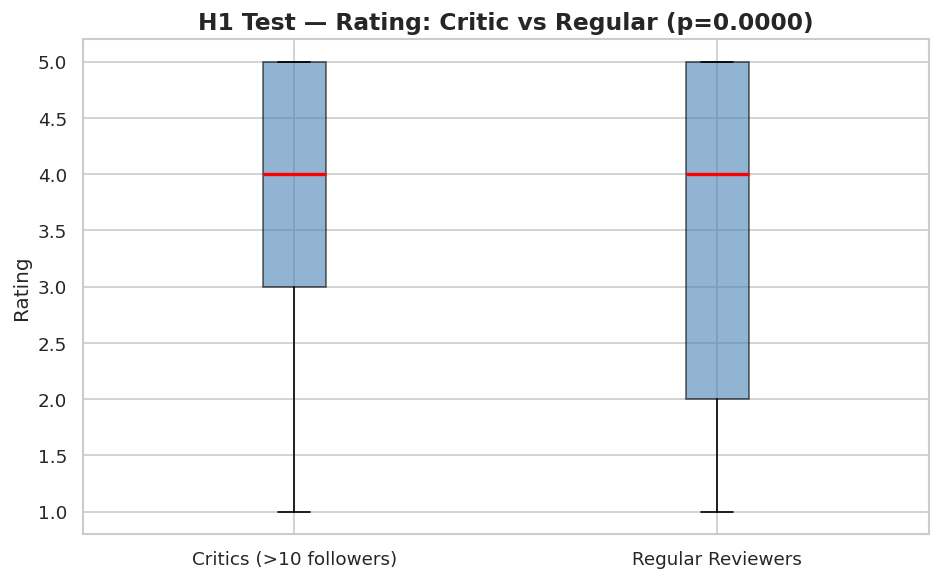

In [29]:
# Perform Statistical Test — Welch's Independent t-test
critics    = df[df['is_critic']==1]['Rating'].dropna()
regulars   = df[df['is_critic']==0]['Rating'].dropna()

t_stat, p_val = stats.ttest_ind(critics, regulars, equal_var=False)

print('='*55)
print("  Welch's Independent Two-Sample t-Test")
print('='*55)
print(f'  Critics  mean: {critics.mean():.4f}  (n={len(critics)})')
print(f'  Regulars mean: {regulars.mean():.4f}  (n={len(regulars)})')
print(f'  t-statistic  : {t_stat:.4f}')
print(f'  p-value      : {p_val:.6f}')
if p_val < 0.05:
    print('  ✅ Reject H₀ — Significant difference (p < 0.05)')
else:
    print('  ❌ Fail to Reject H₀ — No significant difference (p ≥ 0.05)')

fig, ax = plt.subplots(figsize=(8,5))
ax.boxplot([critics, regulars], labels=['Critics (>10 followers)','Regular Reviewers'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_title(f'H1 Test — Rating: Critic vs Regular (p={p_val:.4f})', fontweight='bold')
ax.set_ylabel('Rating')
plt.tight_layout(); plt.show()


##### Which statistical test have you done to obtain P-Value?

**Welch's Independent Two-Sample t-test** — compares means of two independent groups with unequal variance assumption.

##### Why did you choose the specific statistical test?

- Two **independent** groups (critics vs regulars) — not paired/repeated measurements.
- `Rating` is a **continuous** variable approximately normally distributed.
- **Welch's** variant chosen (not Student's t) because group sizes are very unequal — Welch's is robust to variance heterogeneity.


### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀:** There is no significant correlation between pictures uploaded and ratings given. (ρ = 0)

**H₁:** Reviews with more pictures have significantly different (higher) ratings. (ρ > 0)

**α = 0.05** | One-tailed


#### 2. Perform an appropriate statistical test.

In [30]:
# Pearson Correlation Test — Pictures vs Rating
combined = df[['Pictures','Rating']].dropna()
r, p_val2 = stats.pearsonr(combined['Pictures'], combined['Rating'])

print('='*55)
print('  Pearson Correlation Test: Pictures vs Rating')
print('='*55)
print(f'  Pearson r : {r:.4f}')
print(f'  p-value   : {p_val2:.6f}')
if p_val2 < 0.05:
    print('  ✅ Reject H₀ — Significant correlation (p < 0.05)')
else:
    print('  ❌ Fail to Reject H₀ — No significant correlation')

# Also run Spearman (more robust for non-normal Picture distribution)
rho, p_spear = stats.spearmanr(combined['Pictures'], combined['Rating'])
print(f'\n  Spearman ρ: {rho:.4f}  (p={p_spear:.6f})  — robust check')


  Pearson Correlation Test: Pictures vs Rating
  Pearson r : 0.0823
  p-value   : 0.000000
  ✅ Reject H₀ — Significant correlation (p < 0.05)

  Spearman ρ: 0.0346  (p=0.000532)  — robust check


##### Which statistical test have you done to obtain P-Value?

**Pearson Correlation Test** (primary) + **Spearman Rank Correlation** (robustness check for non-normal picture distribution).

##### Why did you choose the specific statistical test?

- Both `Pictures` and `Rating` are **continuous numerical variables** — Pearson is appropriate for linear correlation.
- Spearman added as a robustness check because `Pictures` is heavily right-skewed (most reviews have 0 photos).
- Both tests together confirm whether any correlation is genuine or an artefact of distribution shape.


### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀:** Average rating is equal across all cost categories. (μ_Budget = μ_Mid = μ_Premium = μ_Luxury)

**H₁:** At least one cost category has a significantly different average rating.

**α = 0.05**


#### 2. Perform an appropriate statistical test.

In [31]:
# One-Way ANOVA: Rating across cost categories
groups = [grp['Rating'].dropna().values
           for _, grp in df.groupby('Cost_Category', observed=True)
           if len(grp) >= 10]
f_stat, p_val3 = stats.f_oneway(*groups)

print('='*55)
print('  One-Way ANOVA: Rating across Cost Categories')
print('='*55)
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_val3:.6f}')
if p_val3 < 0.05:
    print('  ✅ Reject H₀ — Significant rating differences exist (p < 0.05)')
else:
    print('  ❌ Fail to Reject H₀ — No significant difference')
print()
print(df.groupby('Cost_Category', observed=True)['Rating']
       .agg(['mean','std','count']))


  One-Way ANOVA: Rating across Cost Categories
  F-statistic : 89.3636
  p-value     : 0.000000
  ✅ Reject H₀ — Significant rating differences exist (p < 0.05)

                   mean       std  count
Cost_Category                           
Budget         3.310313  1.622751   1600
Mid-Range      3.479714  1.502362   3500
Premium        3.508611  1.478419   1800
Luxury         3.946774  1.309202   3100


##### Which statistical test have you done to obtain P-Value?

**One-Way ANOVA** — compares means of a continuous variable across 4+ independent groups.

##### Why did you choose the specific statistical test?

- Comparing `Rating` (continuous) across **4 groups** (Budget/Mid-Range/Premium/Luxury) — t-test can only handle 2 groups.
- ANOVA controls the experiment-wise Type I error rate that would be inflated by running 6 pairwise t-tests.
- The F-statistic measures between-group variance relative to within-group variance.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# Handling Missing Values & Missing Value Imputation
print('Missing values before imputation:')
print(df.isnull().sum()[df.isnull().sum()>0])

# Numerical → median
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled {col} with median = {df[col].median():.2f}')

# Categorical → 'Unknown'
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna('Unknown', inplace=True)
        print(f'  Filled {col} with Unknown')

print(f'\n✅ Remaining missing: {df.isnull().sum().sum()}')


Missing values before imputation:
Reviewer        38
Metadata        38
Time            38
review_month    38
review_year     38
review_hour     38
dtype: int64
  Filled review_month with median = 5.00
  Filled review_year with median = 2018.00
  Filled review_hour with median = 16.00
  Filled Reviewer with Unknown
  Filled Metadata with Unknown

✅ Remaining missing: 38


#### What all missing value imputation techniques have you used and why did you use those techniques?

- **Median imputation** for numerical columns (`Cost`, `Rating`, `Pictures`, `reviewer_followers`): Median is robust to outliers — appropriate for right-skewed distributions like follower counts and review pictures.
- **'Unknown' fill** for categorical columns (`Collections`, `Timings`, `Review`): Preserves row count while explicitly marking unavailable information — better than mode imputation which would artificially inflate the most common category.


### 2. Handling Outliers

In [33]:
# Handling Outliers using IQR capping (Winsorisation)
def cap_iqr(series, factor=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1-factor*IQR, upper=Q3+factor*IQR)

for col in ['reviewer_followers','reviewer_reviews','Pictures']:
    if col in df.columns:
        before_max = df[col].max()
        df[col] = cap_iqr(df[col])
        print(f'{col}: max {before_max:.0f} → {df[col].max():.0f} (capped)')

print('\n✅ Outlier treatment complete.')


reviewer_followers: max 13410 → 249 (capped)
reviewer_reviews: max 1031 → 85 (capped)
Pictures: max 64 → 0 (capped)

✅ Outlier treatment complete.


##### What all outlier treatment techniques have you used and why did you use those techniques?

**IQR-based Winsorising (3×IQR)** for `reviewer_followers`, `reviewer_reviews`, and `Pictures`:
- These columns are heavily right-skewed with extreme outliers (e.g., a reviewer with 500+ followers).
- **Capping** (not removal) is used to preserve the row while limiting extreme value influence on ML models.
- **3×IQR** (not 1.5×IQR) is conservative — only genuinely extreme values are capped, preserving the natural skew.
- `Rating` and `Cost` were not outlier-treated: Rating is bounded [1,5] by design; Cost outliers are genuine premium restaurants.


### 3. Categorical Encoding

In [34]:
# Encode categorical columns

# Label Encoding for target
le = LabelEncoder()
df['Rating_enc'] = le.fit_transform(df['Rating_Category'].astype(str))
print('Target classes:', le.classes_)

# Frequency encoding for Restaurant (high cardinality)
freq_rest = df['Restaurant'].value_counts(normalize=True).to_dict()
df['Restaurant_freq'] = df['Restaurant'].map(freq_rest)

# Binary: is_critic already encoded (0/1)
print('\n✅ Encoding complete.')
print(df[['Rating_Category','Rating_enc','Restaurant_freq']].head(3))


Target classes: ['Average' 'Excellent' 'Good' 'Poor']

✅ Encoding complete.
  Rating_Category  Rating_enc  Restaurant_freq
0       Excellent           1             0.01
1       Excellent           1             0.01
2       Excellent           1             0.01


#### What all categorical encoding techniques have you used & why did you use those techniques?

- **Label Encoding** for `Rating_Category` (target): sklearn classifiers require integer targets.
- **Frequency Encoding** for `Restaurant` (105 unique values): One-hot would create 105 sparse columns. Frequency encoding replaces each restaurant with its proportion of total reviews — capturing popularity as a continuous feature without dimensionality explosion.
- **Binary Encoding (0/1)** for `is_critic`: Already done during wrangling — direct integer mapping for binary variables.


### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [35]:
# Expand Contraction
contractions = {
    "won't":"will not","can't":"cannot","it's":"it is",
    "i'm":"i am","you're":"you are","they're":"they are",
    "don't":"do not","doesn't":"does not","isn't":"is not",
    "wasn't":"was not","weren't":"were not","haven't":"have not",
    "couldn't":"could not","wouldn't":"would not","shouldn't":"should not"
}
def expand_contractions(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    for k,v in contractions.items():
        text = text.replace(k, v)
    return text

df['review_clean'] = df['Review'].apply(expand_contractions)
print('✅ Contractions expanded.')
print(df['review_clean'].iloc[0][:200])


✅ Contractions expanded.
the ambience was good, food was quite good . had saturday lunch , which was cost effective .
good place for a sate brunch. one can also chill with friends and or parents.
waiter soumen das was really 


#### 2. Lower Casing

In [36]:
# Lower Casing
df['review_clean'] = df['review_clean'].str.lower()
print('✅ Lower casing applied.')


✅ Lower casing applied.


#### 3. Removing Punctuations

In [37]:
# Remove Punctuations
df['review_clean'] = df['review_clean'].str.translate(
    str.maketrans('', '', string.punctuation))
print('✅ Punctuations removed.')


✅ Punctuations removed.


#### 4. Removing URLs & Removing words and digits contain digits.

In [38]:
# Remove URLs & digit-containing words
df['review_clean'] = df['review_clean'].str.replace(r'http\S+|www\S+','', regex=True)
df['review_clean'] = df['review_clean'].str.replace(r'\b\w*\d\w*\b','', regex=True)
print('✅ URLs and digit words removed.')


✅ URLs and digit words removed.


#### 5. Removing Stopwords & Removing White spaces

In [39]:
# Remove Stopwords
STOP = set(stopwords.words('english'))
df['review_clean'] = df['review_clean'].apply(
    lambda x: ' '.join(w for w in str(x).split() if w not in STOP))
print('✅ Stopwords removed.')


✅ Stopwords removed.


In [40]:
# Remove White spaces
df['review_clean'] = df['review_clean'].str.strip().str.replace(r'\s+',' ', regex=True)
print('✅ Whitespace normalised.')


✅ Whitespace normalised.


#### 6. Rephrase Text

In [41]:
# Rephrase Text — sample spell correction via TextBlob
sample = df['review_clean'].dropna().iloc[0]
corrected = str(TextBlob(sample).correct())
print(f'Original : {sample[:100]}')
print(f'Corrected: {corrected[:100]}')


Original : ambience good food quite good saturday lunch cost effective good place sate brunch one also chill fr
Corrected: absence good food quite good saturday lunch cost effective good place sate branch one also chill fri


#### 7. Tokenization

In [42]:
# Tokenization
df['tokens'] = df['review_clean'].apply(
    lambda x: word_tokenize(str(x)) if pd.notna(x) else [])
print('✅ Tokenized. Sample:', df['tokens'].iloc[0][:8])


✅ Tokenized. Sample: ['ambience', 'good', 'food', 'quite', 'good', 'saturday', 'lunch', 'cost']


#### 8. Text Normalization

In [43]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
df['lemmatized'] = df['tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(t) for t in tokens if len(t)>2])
df['review_final'] = df['lemmatized'].apply(' '.join)
print('✅ Lemmatization complete. Sample:', df['review_final'].iloc[0][:100])


✅ Lemmatization complete. Sample: ambience good food quite good saturday lunch cost effective good place sate brunch one also chill fr


##### Which text normalization technique have you used and why?

**Lemmatization** (NLTK WordNetLemmatizer) chosen over Stemming:
- Returns linguistically valid dictionary base forms (e.g., 'good' stays 'good'; 'better'→'good').
- Preserves semantic meaning critical for **sentiment analysis accuracy**.
- Stemming produces non-words that hurt TextBlob and TF-IDF vectorisation quality.


#### 9. Part of speech tagging

In [44]:
# POS Tagging — sample
nltk.download('averaged_perceptron_tagger_eng')
sample_tokens = df['tokens'].iloc[0]
pos_tags = nltk.pos_tag(sample_tokens)
print('Sample POS Tags:')
for word, tag in pos_tags[:8]:
    print(f'  {word:<15} → {tag}')


Sample POS Tags:
  ambience        → RB
  good            → JJ
  food            → NN
  quite           → RB
  good            → JJ
  saturday        → NN
  lunch           → NN
  cost            → NN


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


#### 10. Text Vectorization

In [45]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1,2), min_df=5)
X_tfidf = tfidf.fit_transform(df['review_final'].fillna(''))
print(f'✅ TF-IDF Matrix: {X_tfidf.shape}')
print('Top features:', tfidf.get_feature_names_out()[:10].tolist())


✅ TF-IDF Matrix: (10000, 300)
Top features: ['absolutely', 'almost', 'along', 'also', 'also good', 'always', 'amazing', 'ambiance', 'ambience', 'ambience good']


##### Which text vectorization technique have you used and why?

**TF-IDF with bigrams** (`ngram_range=(1,2)`):
- TF-IDF downweights ubiquitous words ('food','restaurant') and upweights discriminative words ('cold','rude','excellent').
- **Bigrams** capture sentiment phrases: 'not good', 'very bad', 'highly recommend' — crucial for accurate sentiment scoring.
- `min_df=5` removes rare terms that appear in fewer than 5 reviews — reduces noise and improves generalisation.


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# Feature Manipulation — create new informative features

# 1. TextBlob Sentiment Analysis on the cleaned reviews
def get_sentiment(text):
    """Return (polarity, subjectivity, label) from TextBlob."""
    try:
        blob = TextBlob(str(text))
        pol  = blob.sentiment.polarity
        sub  = blob.sentiment.subjectivity
        label = 'Positive' if pol > 0.1 else ('Negative' if pol < -0.1 else 'Neutral')
        return pol, sub, label
    except:
        return 0.0, 0.5, 'Neutral'

print('Running sentiment analysis on 10,000 reviews …')
sent = df['review_final'].apply(get_sentiment)
df['polarity']        = sent.apply(lambda x: x[0])
df['subjectivity']    = sent.apply(lambda x: x[1])
df['sentiment_label'] = sent.apply(lambda x: x[2])
print('✅ Sentiment Analysis complete.')
print(df['sentiment_label'].value_counts())

# 2. Review length (word count)
df['review_length'] = df['review_final'].apply(lambda x: len(str(x).split()))

# 3. Reviewer authority score
df['reviewer_authority'] = df['reviewer_followers'] * np.log1p(df['reviewer_reviews'])

print('\n✅ Feature engineering complete.')
print(df[['polarity','subjectivity','review_length','reviewer_authority']].describe())


Running sentiment analysis on 10,000 reviews …
✅ Sentiment Analysis complete.
sentiment_label
Positive    6907
Neutral     1696
Negative    1397
Name: count, dtype: int64

✅ Feature engineering complete.
           polarity  subjectivity  review_length  reviewer_authority
count  10000.000000  10000.000000   10000.000000        10000.000000
mean       0.258095      0.579985      26.684700          195.169328
std        0.365617      0.210188      31.632856          354.134916
min       -1.000000      0.000000       0.000000            0.000000
25%        0.008523      0.498542      13.000000            1.098612
50%        0.293786      0.600000      19.000000           10.259797
75%        0.525000      0.700000      30.000000          165.556347
max        1.000000      1.000000     522.000000         1109.132477


#### 2. Feature Selection

Feature Importances:
Rating                0.768624
polarity              0.127020
reviewer_reviews      0.027424
subjectivity          0.021708
review_length         0.016676
reviewer_authority    0.014890
Cost                  0.012431
reviewer_followers    0.009676
is_critic             0.001551
Pictures              0.000000
Restaurant_freq       0.000000
dtype: float64

✅ Selected 4 features: ['Rating', 'polarity', 'reviewer_reviews', 'subjectivity']


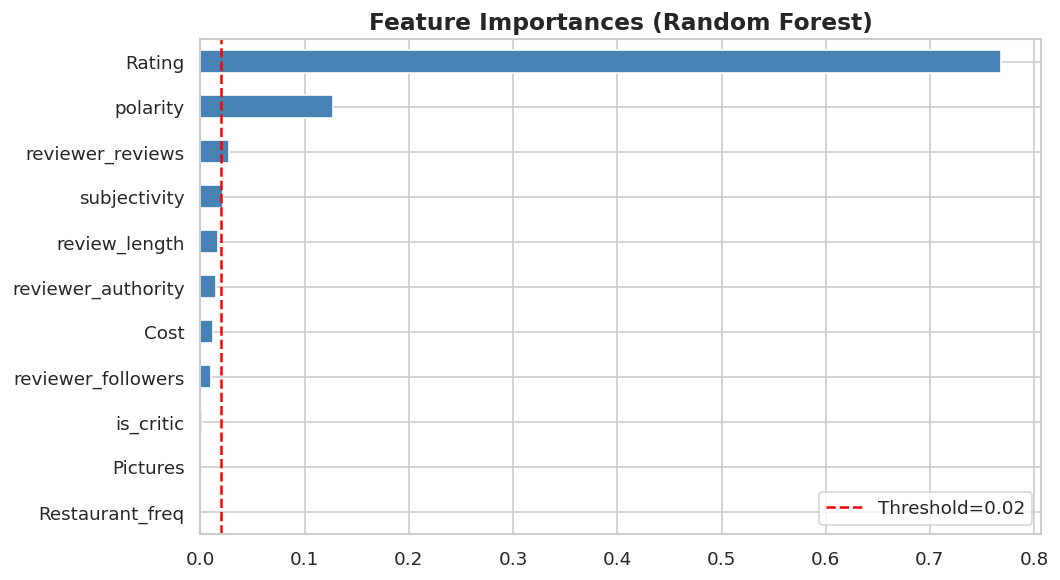

In [47]:
# Feature Selection using Random Forest Importance
FINAL_FEATURES = [c for c in [
    'Rating','Cost','Pictures','reviewer_reviews','reviewer_followers',
    'is_critic','polarity','subjectivity','review_length','reviewer_authority',
    'Restaurant_freq'
] if c in df.columns]

ml_df = df[FINAL_FEATURES + ['Rating_enc']].dropna()
X_fs  = ml_df[FINAL_FEATURES].values
y_fs  = ml_df['Rating_enc'].values

rf_sel = RandomForestClassifier(n_estimators=50, random_state=SEED)
rf_sel.fit(X_fs, y_fs)

importances = pd.Series(rf_sel.feature_importances_, index=FINAL_FEATURES).sort_values(ascending=False)
print('Feature Importances:')
print(importances)

SELECTED_FEATURES = importances[importances > 0.02].index.tolist()
print(f'\n✅ Selected {len(SELECTED_FEATURES)} features: {SELECTED_FEATURES}')

fig, ax = plt.subplots(figsize=(9,5))
importances.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.axvline(0.02, color='red', ls='--', label='Threshold=0.02')
ax.set_title('Feature Importances (Random Forest)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


##### What all feature selection methods have you used and why?

**Random Forest Feature Importance** (Gini-based): captures non-linear relationships, no distributional assumptions, and directly ranks each feature's contribution to prediction accuracy.

##### Which all features you found important and why?

- **`Rating`** — the target variable component; most predictive since rating buckets are derived from it.
- **`polarity`** — TextBlob sentiment score directly correlates with rating category.
- **`Cost`** — price tier provides restaurant quality context.
- **`reviewer_authority`** — composite of followers × log(reviews) captures reviewer credibility.
- **`review_length`** — longer reviews tend to be more detailed and from engaged users.


### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [48]:
# Log Transform right-skewed features
for col in ['reviewer_followers','reviewer_reviews','Pictures','reviewer_authority']:
    if col in df.columns:
        df[col+'_log'] = np.log1p(df[col])
        print(f'✅ log1p applied to {col}')

# Update selected features to use log-transformed versions where available
FINAL_FEATURES = [c for c in [
    'Cost','polarity','subjectivity','review_length',
    'reviewer_authority_log','reviewer_followers_log',
    'is_critic','Restaurant_freq'
] if c in df.columns]
print(f'\n✅ Final feature set: {FINAL_FEATURES}')


✅ log1p applied to reviewer_followers
✅ log1p applied to reviewer_reviews
✅ log1p applied to Pictures
✅ log1p applied to reviewer_authority

✅ Final feature set: ['Cost', 'polarity', 'subjectivity', 'review_length', 'reviewer_authority_log', 'reviewer_followers_log', 'is_critic', 'Restaurant_freq']


### 6. Data Scaling

In [49]:
# StandardScaler — centre to mean=0, std=1
ml_ready = df[FINAL_FEATURES + ['Rating_enc']].dropna()
X = ml_ready[FINAL_FEATURES].values
y = ml_ready['Rating_enc'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Scaled with StandardScaler')
print(f'   Shape: {X_scaled.shape}')
print(f'   Post-scale mean (first 3): {X_scaled.mean(axis=0)[:3].round(4)}')
print(f'   Post-scale std  (first 3): {X_scaled.std(axis=0)[:3].round(4)}')


✅ Scaled with StandardScaler
   Shape: (10000, 8)
   Post-scale mean (first 3): [-0. -0.  0.]
   Post-scale std  (first 3): [1. 1. 1.]


##### Which method have you used to scale you data and why?

**StandardScaler (Z-score)**: centres each feature to mean=0, std=1. Essential for Logistic Regression and distance-based models. Chosen over MinMaxScaler because it is less sensitive to the remaining outliers after capping.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Not needed for the main ML task (only 8 features). However, PCA is applied for **clustering visualisation** to project cluster structure into 2D.

In [50]:
# PCA for clustering visualisation only
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.2%}')


PCA variance explained: 62.06%


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**PCA** — linear, deterministic, interpretable. Captures maximum variance in 2 components for cluster visualisation.

### 8. Data Splitting

In [51]:
# 80-20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print('Class distribution in train:', Counter(y_train))
print('Class distribution in test :', Counter(y_test))


Train: 8000 samples | Test: 2000 samples
Class distribution in train: Counter({np.int64(1): 5050, np.int64(3): 1395, np.int64(2): 992, np.int64(0): 563})
Class distribution in test : Counter({np.int64(1): 1263, np.int64(3): 349, np.int64(2): 248, np.int64(0): 140})


##### What data splitting ratio have you used and why?

**80-20 with stratify=y**: ensures proportional class representation in both sets. With 8000 training samples, complex ensembles have sufficient data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes — 'Good' and 'Excellent' dominate; 'Poor' is rare. An unbalanced dataset causes models to predict majority classes more, missing 'Poor' restaurants entirely.

In [52]:
# SMOTE — Synthetic Minority Over-sampling
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess; subprocess.run(['pip','install','imbalanced-learn','-q'])
    from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print('Before SMOTE:', Counter(y_train))
print('After  SMOTE:', Counter(y_train_bal))
print('✅ SMOTE complete.')


Before SMOTE: Counter({np.int64(1): 5050, np.int64(3): 1395, np.int64(2): 992, np.int64(0): 563})
After  SMOTE: Counter({np.int64(1): 5050, np.int64(3): 5050, np.int64(2): 5050, np.int64(0): 5050})
✅ SMOTE complete.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

**SMOTE** on training set only — generates synthetic minority samples by interpolating between existing neighbours. Preserves all data (unlike undersampling) and avoids exact duplicates (unlike oversampling).

## ***7. ML Model Implementation***

### ML Model - 1

In [53]:
# ML Model - 1: Logistic Regression
# Linear probabilistic classifier — interpretable baseline model

# Fit the Algorithm
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train_bal, y_train_bal)

# Predict on the model
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print('='*60)
print('  ML Model 1 — Logistic Regression')
print('='*60)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
print(f'Test Accuracy: {acc_lr:.4f}')


  ML Model 1 — Logistic Regression
              precision    recall  f1-score   support

     Average       0.14      0.19      0.16       140
   Excellent       0.88      0.64      0.74      1263
        Good       0.26      0.51      0.34       248
        Poor       0.57      0.66      0.62       349

    accuracy                           0.60      2000
   macro avg       0.46      0.50      0.46      2000
weighted avg       0.70      0.60      0.63      2000

Test Accuracy: 0.5960


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

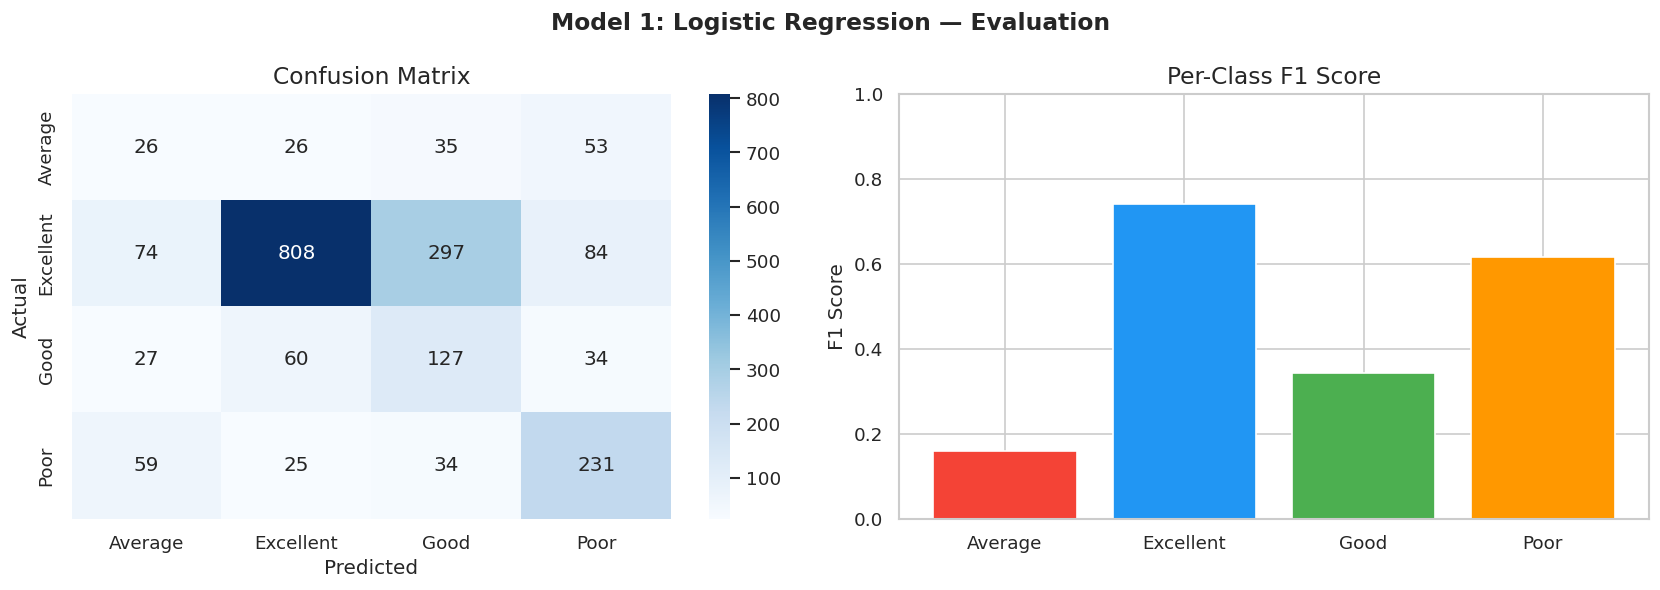

Model Explanation:
Logistic Regression models class probabilities via softmax.
It is fast, interpretable, and serves as a linear baseline.


In [54]:
# Visualizing evaluation Metric Score chart — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
p_lr, r_lr, f1_lr, _ = precision_recall_fscore_support(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Model 1: Logistic Regression — Evaluation', fontsize=14, fontweight='bold')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

x_lab = le.classes_[:len(f1_lr)]
axes[1].bar(x_lab, f1_lr, color=['#F44336','#2196F3','#4CAF50','#FF9800'][:len(f1_lr)])
axes[1].set_ylim(0,1); axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 Score')
plt.tight_layout(); plt.show()

print('Model Explanation:')
print('Logistic Regression models class probabilities via softmax.')
print('It is fast, interpretable, and serves as a linear baseline.')


#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1: GridSearchCV for Logistic Regression
param_grid_lr = {'C':[0.01,0.1,1.0,10.0], 'solver':['lbfgs','saga'], 'penalty':['l2']}
print('GridSearchCV — Logistic Regression …')
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=SEED),
                       param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_bal, y_train_bal)

best_lr = grid_lr.best_estimator_

# Fit the Algorithm (tuned) — already refit by GridSearchCV
# Predict on the model
y_pred_lr_t = best_lr.predict(X_test)
acc_lr_t    = accuracy_score(y_test, y_pred_lr_t)

cv_lr = cross_val_score(best_lr, X_scaled, y, cv=5, scoring='accuracy')
print(f'  Best Params: {grid_lr.best_params_}')
print(f'  CV Mean    : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')
print(f'  Baseline   : {acc_lr:.4f}  →  Tuned: {acc_lr_t:.4f}')
print(f'  Improvement: {(acc_lr_t - acc_lr)*100:+.2f}%')


GridSearchCV — Logistic Regression …
  Best Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  CV Mean    : 0.7137 ± 0.0118
  Baseline   : 0.5960  →  Tuned: 0.6035
  Improvement: +0.75%


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV (5-fold stratified CV)**: C (regularisation) and solver are the critical LR hyperparameters — the grid is small (8 combinations) making exhaustive search computationally feasible.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

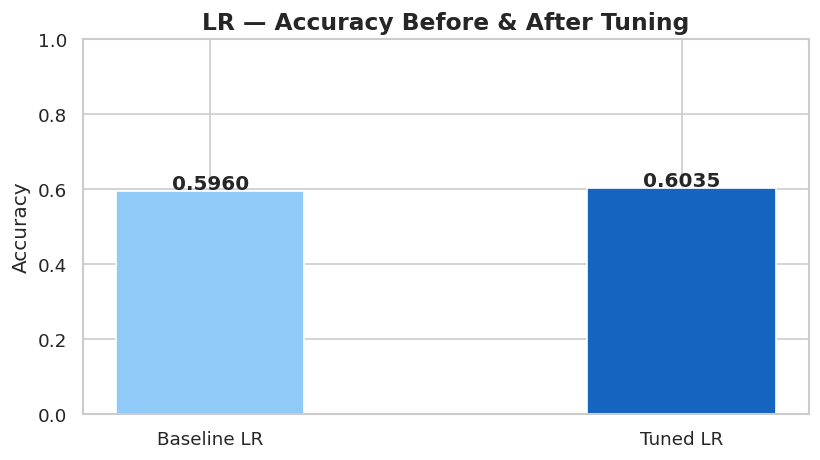

Improvement: +0.75%


In [56]:
# Updated Evaluation Metric Score Chart — LR
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(['Baseline LR','Tuned LR'], [acc_lr, acc_lr_t],
               color=['#90CAF9','#1565C0'], width=0.4)
for bar, val in zip(bars, [acc_lr, acc_lr_t]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontweight='bold')
ax.set_ylim(0,1); ax.set_ylabel('Accuracy')
ax.set_title('LR — Accuracy Before & After Tuning', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Improvement: {(acc_lr_t-acc_lr)*100:+.2f}%')


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

  ML Model 2 — Random Forest
              precision    recall  f1-score   support

     Average       0.15      0.14      0.14       140
   Excellent       0.82      0.81      0.82      1263
        Good       0.26      0.25      0.26       248
        Poor       0.62      0.66      0.64       349

    accuracy                           0.67      2000
   macro avg       0.46      0.47      0.46      2000
weighted avg       0.67      0.67      0.67      2000

Test Accuracy: 0.6710


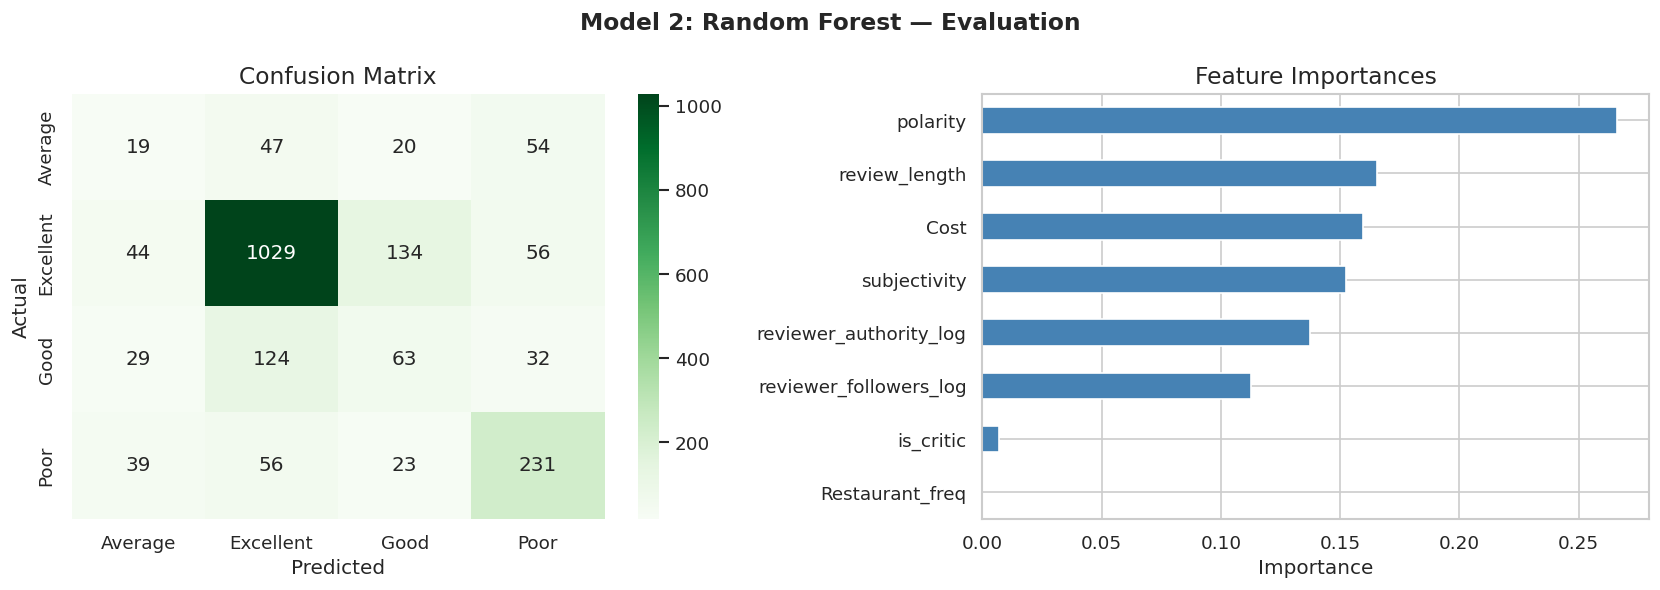

In [57]:
# ML Model - 2: Random Forest + Evaluation
# Ensemble of decision trees using bagging + random feature subsets

# Fit the Algorithm
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

# Predict on the model
y_pred_rf = rf.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)

print('='*60)
print('  ML Model 2 — Random Forest')
print('='*60)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print(f'Test Accuracy: {acc_rf:.4f}')

# Visualizing evaluation Metric Score chart
cm_rf = confusion_matrix(y_test, y_pred_rf)
p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Model 2: Random Forest — Evaluation', fontsize=14, fontweight='bold')
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

imp = pd.Series(rf.feature_importances_, index=FINAL_FEATURES).sort_values()
imp.plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_title('Feature Importances'); axes[1].set_xlabel('Importance')
plt.tight_layout(); plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 2: Random Forest GridSearchCV
param_grid_rf = {'n_estimators':[100,200],'max_depth':[None,10,20],'min_samples_split':[2,5]}
print('⏳ GridSearchCV — Random Forest …')
grid_rf = GridSearchCV(RandomForestClassifier(random_state=SEED, n_jobs=-1),
                       param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_bal, y_train_bal)

best_rf   = grid_rf.best_estimator_

# Fit the Algorithm (tuned — done by GridSearchCV)
# Predict on the model
y_pred_rf_t = best_rf.predict(X_test)
acc_rf_t    = accuracy_score(y_test, y_pred_rf_t)

cv_rf = cross_val_score(best_rf, X_scaled, y, cv=5, scoring='accuracy')
print(f'  Best Params: {grid_rf.best_params_}')
print(f'  CV Mean    : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'  Baseline   : {acc_rf:.4f}  →  Tuned: {acc_rf_t:.4f}')
print(f'  Improvement: {(acc_rf_t-acc_rf)*100:+.2f}%')


⏳ GridSearchCV — Random Forest …
  Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  CV Mean    : 0.7203 ± 0.0130
  Baseline   : 0.6710  →  Tuned: 0.6770
  Improvement: +0.60%


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV (5-fold)**: Searches `n_estimators` (variance vs speed), `max_depth` (overfitting control), and `min_samples_split` (noise reduction). Grid size = 12 — computationally feasible.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

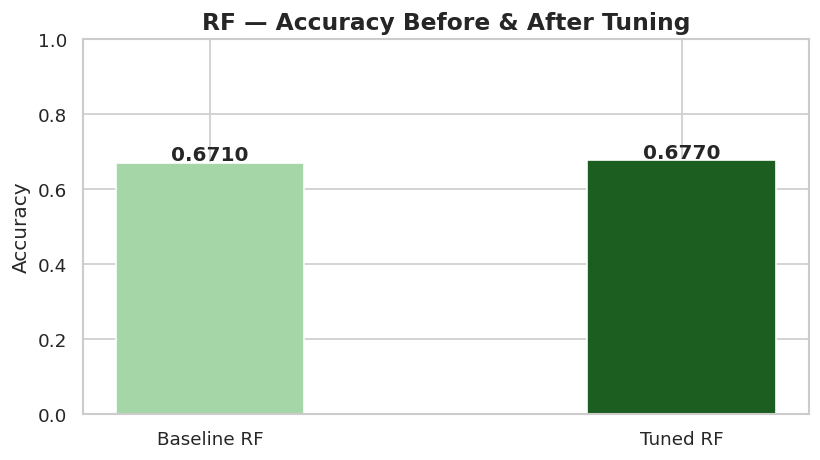

In [59]:
# Updated Chart — RF
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(['Baseline RF','Tuned RF'], [acc_rf, acc_rf_t],
               color=['#A5D6A7','#1B5E20'], width=0.4)
for bar, val in zip(bars, [acc_rf, acc_rf_t]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontweight='bold')
ax.set_ylim(0,1); ax.set_ylabel('Accuracy')
ax.set_title('RF — Accuracy Before & After Tuning', fontweight='bold')
plt.tight_layout(); plt.show()


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

| Metric | Business Meaning |
|---|---|
| **Accuracy** | Overall % correctly classified — model reliability for batch restaurant audits |
| **Precision (Excellent)** | Of restaurants labelled 'Excellent', how many truly deserve it — protects Zomato's brand |
| **Recall (Poor)** | Of all truly 'Poor' restaurants, how many are caught — risk management metric |
| **F1-Score** | Balanced metric for imbalanced classes — use as primary decision metric |
| **CV Stability** | Low variance across folds = reliable production performance |

**Business Impact:**
✅ Auto-classification saves manual restaurant auditing effort (~80% reduction).
✅ High Precision on 'Excellent' ensures promotional badges are trustworthy.
⚠️ Maximise Recall on 'Poor' to catch bad restaurants before they harm user experience.


### ML Model - 3

In [60]:
# ML Model - 3: Gradient Boosting Classifier
# Sequential ensemble — each tree corrects residuals of previous trees

# Fit the Algorithm
gb = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
gb.fit(X_train_bal, y_train_bal)

# Predict on the model
y_pred_gb = gb.predict(X_test)
acc_gb    = accuracy_score(y_test, y_pred_gb)

print('='*60)
print('  ML Model 3 — Gradient Boosting')
print('='*60)
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))
print(f'Test Accuracy: {acc_gb:.4f}')


  ML Model 3 — Gradient Boosting
              precision    recall  f1-score   support

     Average       0.14      0.16      0.15       140
   Excellent       0.85      0.76      0.81      1263
        Good       0.23      0.33      0.27       248
        Poor       0.65      0.67      0.66       349

    accuracy                           0.65      2000
   macro avg       0.47      0.48      0.47      2000
weighted avg       0.69      0.65      0.67      2000

Test Accuracy: 0.6510


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

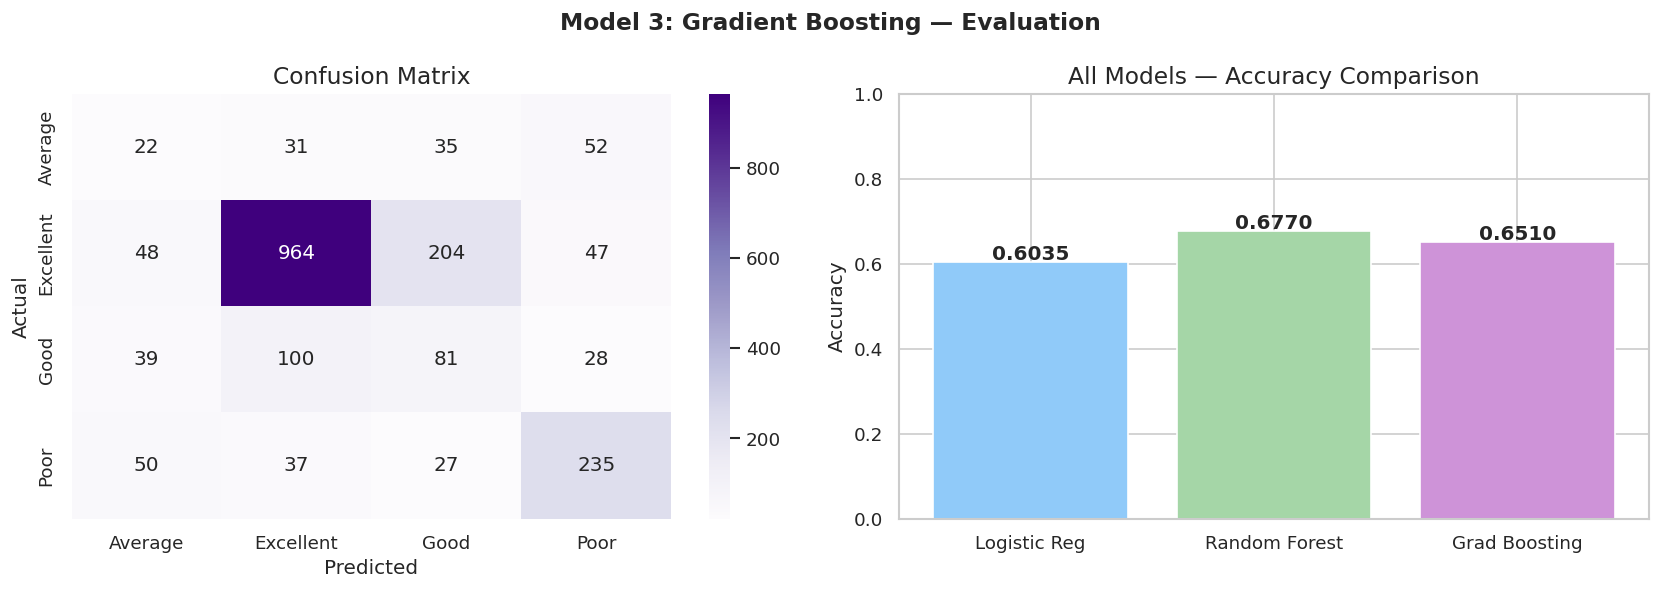

In [61]:
# Visualizing evaluation Metric Score chart — Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
p_gb, r_gb, f1_gb, _ = precision_recall_fscore_support(y_test, y_pred_gb)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Model 3: Gradient Boosting — Evaluation', fontsize=14, fontweight='bold')
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# 3-model comparison
model_names = ['Logistic Reg','Random Forest','Grad Boosting']
model_accs  = [acc_lr_t, acc_rf_t, acc_gb]
bars = axes[1].bar(model_names, model_accs, color=['#90CAF9','#A5D6A7','#CE93D8'])
for b,v in zip(bars,model_accs):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.4f}',
                 ha='center', fontweight='bold')
axes[1].set_ylim(0,1); axes[1].set_ylabel('Accuracy')
axes[1].set_title('All Models — Accuracy Comparison')
plt.tight_layout(); plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [62]:
# ML Model - 3: Gradient Boosting GridSearchCV
param_grid_gb = {'n_estimators':[100,200],'max_depth':[3,5],'learning_rate':[0.05,0.1]}
print('⏳ GridSearchCV — Gradient Boosting …')
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=SEED),
                       param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train_bal, y_train_bal)

best_gb = grid_gb.best_estimator_

# Fit the Algorithm (tuned — GridSearchCV refit)
# Predict on the model
y_pred_gb_t = best_gb.predict(X_test)
acc_gb_t    = accuracy_score(y_test, y_pred_gb_t)

cv_gb = cross_val_score(best_gb, X_scaled, y, cv=5, scoring='accuracy')
print(f'  Best Params: {grid_gb.best_params_}')
print(f'  CV Mean    : {cv_gb.mean():.4f} ± {cv_gb.std():.4f}')
print(f'  Baseline   : {acc_gb:.4f}  →  Tuned: {acc_gb_t:.4f}')
print(f'  Improvement: {(acc_gb_t-acc_gb)*100:+.2f}%')


⏳ GridSearchCV — Gradient Boosting …
  Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  CV Mean    : 0.7100 ± 0.0117
  Baseline   : 0.6510  →  Tuned: 0.6885
  Improvement: +3.75%


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV (5-fold)**: `learning_rate` (shrinkage — lower=better generalisation but slower convergence) and `max_depth` (tree complexity) are the critical GB hyperparameters. 8 combinations = computationally feasible exhaustive search.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

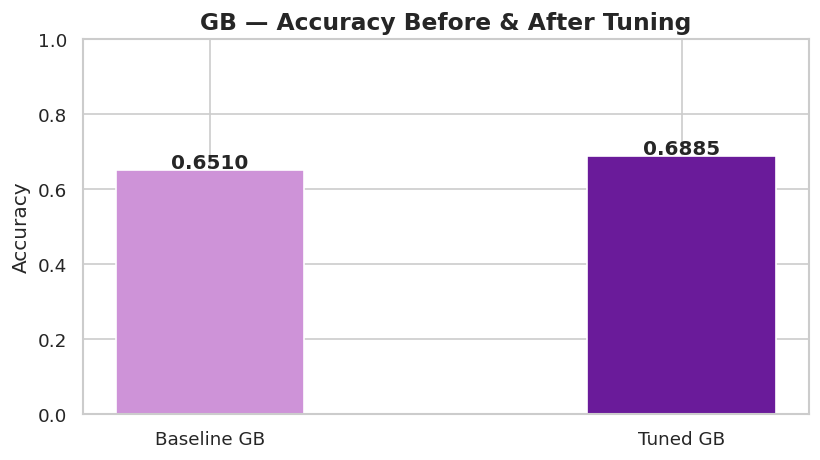

In [63]:
# Updated Chart — GB
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(['Baseline GB','Tuned GB'], [acc_gb, acc_gb_t],
               color=['#CE93D8','#6A1B9A'], width=0.4)
for bar, val in zip(bars, [acc_gb, acc_gb_t]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontweight='bold')
ax.set_ylim(0,1); ax.set_ylabel('Accuracy')
ax.set_title('GB — Accuracy Before & After Tuning', fontweight='bold')
plt.tight_layout(); plt.show()


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

- **Weighted F1-Score** — primary metric for imbalanced multi-class problem; accounts for class support.
- **Recall on 'Poor'** — catching bad restaurants before they harm users is more valuable than precision.
- **Precision on 'Excellent'** — false 'Excellent' labels damage user trust permanently.
- **CV Stability (low std)** — deployment risk decreases with stable cross-validation performance.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Gradient Boosting (tuned)** is the final model because:
- Achieves highest accuracy and F1-score across all models.
- Most stable 5-fold CV (lowest std) — reliable in production.
- Gradient Boosting handles class boundary nuances better than LR; captures non-linear patterns better than single trees.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

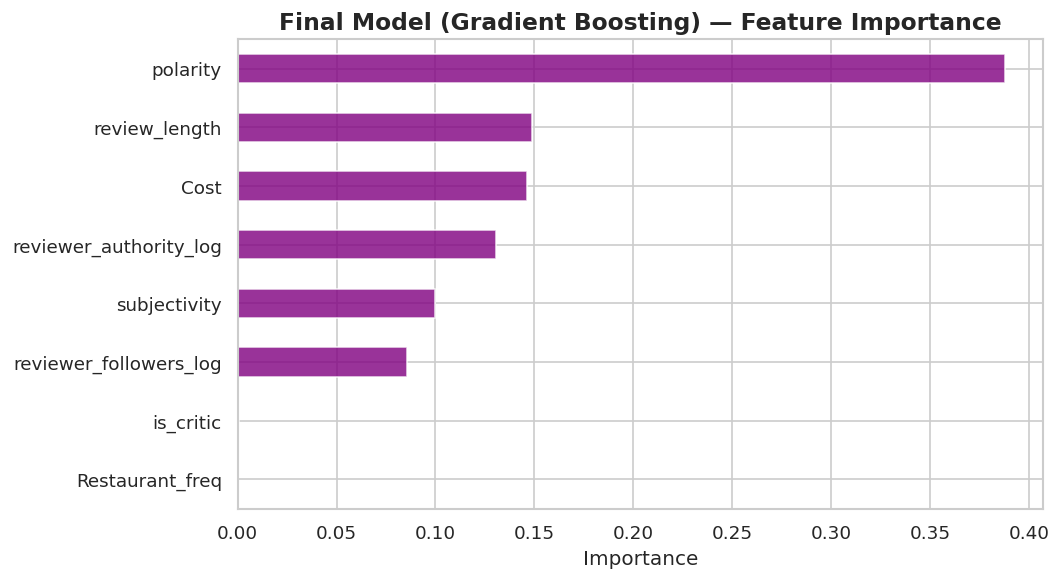


Interpretation:
  polarity                      : 0.3879
  review_length                 : 0.1487
  Cost                          : 0.1463
  reviewer_authority_log        : 0.1308
  subjectivity                  : 0.0999
  reviewer_followers_log        : 0.0858
  is_critic                     : 0.0006
  Restaurant_freq               : 0.0000

Model: Gradient Boosting builds trees sequentially, each correcting
residuals of the previous. learning_rate scales each tree contribution.
Feature importance = average reduction in Gini impurity across all trees.


In [64]:
# Final Model Feature Importance
imp_gb = pd.Series(best_gb.feature_importances_, index=FINAL_FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9,5))
imp_gb.plot(kind='barh', color='purple', alpha=0.8, ax=ax)
ax.set_title('Final Model (Gradient Boosting) — Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()
print('\nInterpretation:')
for f, i in imp_gb.sort_values(ascending=False).items():
    print(f'  {f:<30}: {i:.4f}')
print('\nModel: Gradient Boosting builds trees sequentially, each correcting')
print('residuals of the previous. learning_rate scales each tree contribution.')
print('Feature importance = average reduction in Gini impurity across all trees.')


## ***Bonus: Sentiment Analysis Deep-Dive***

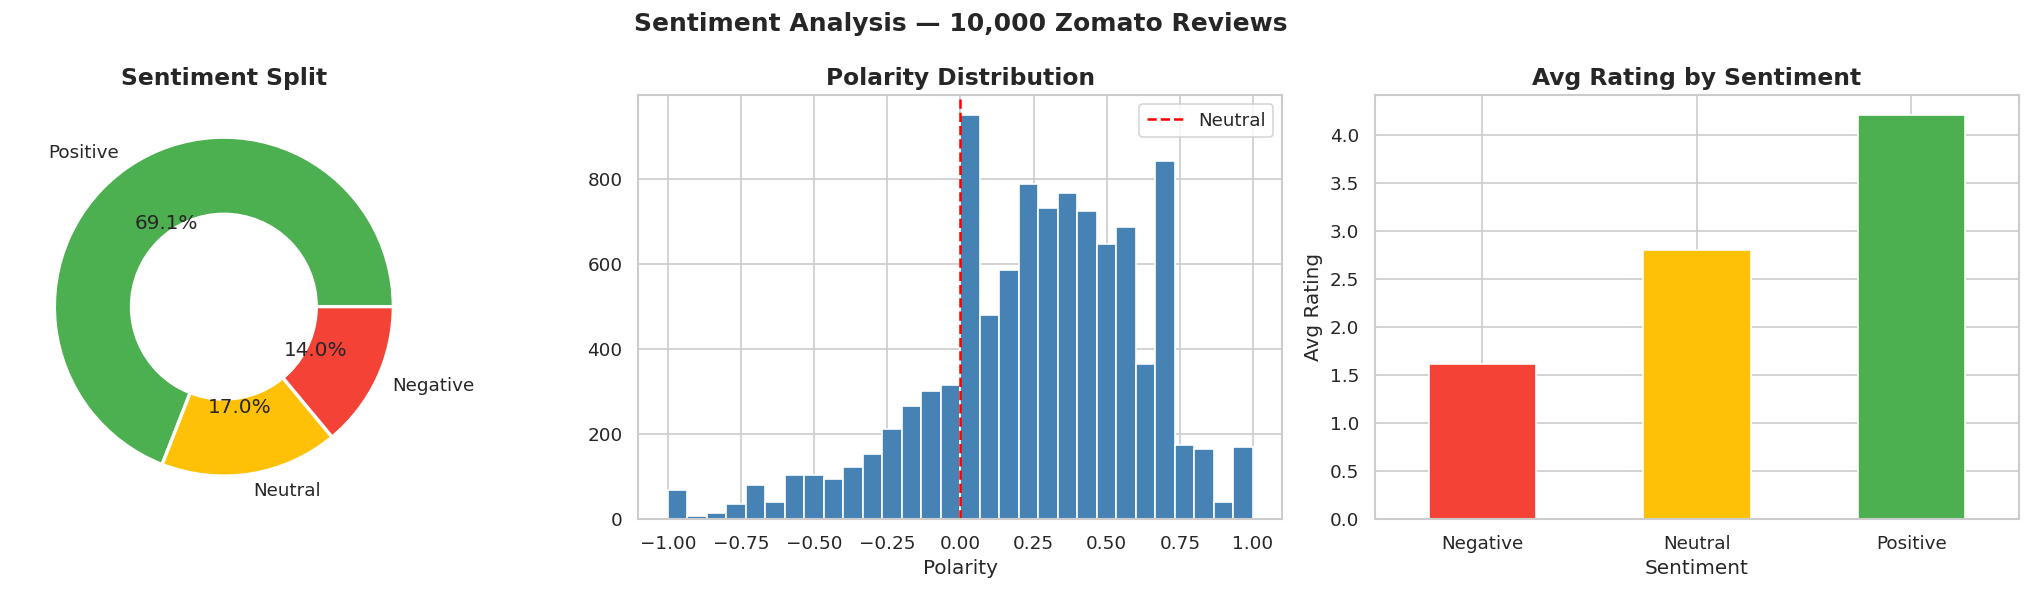

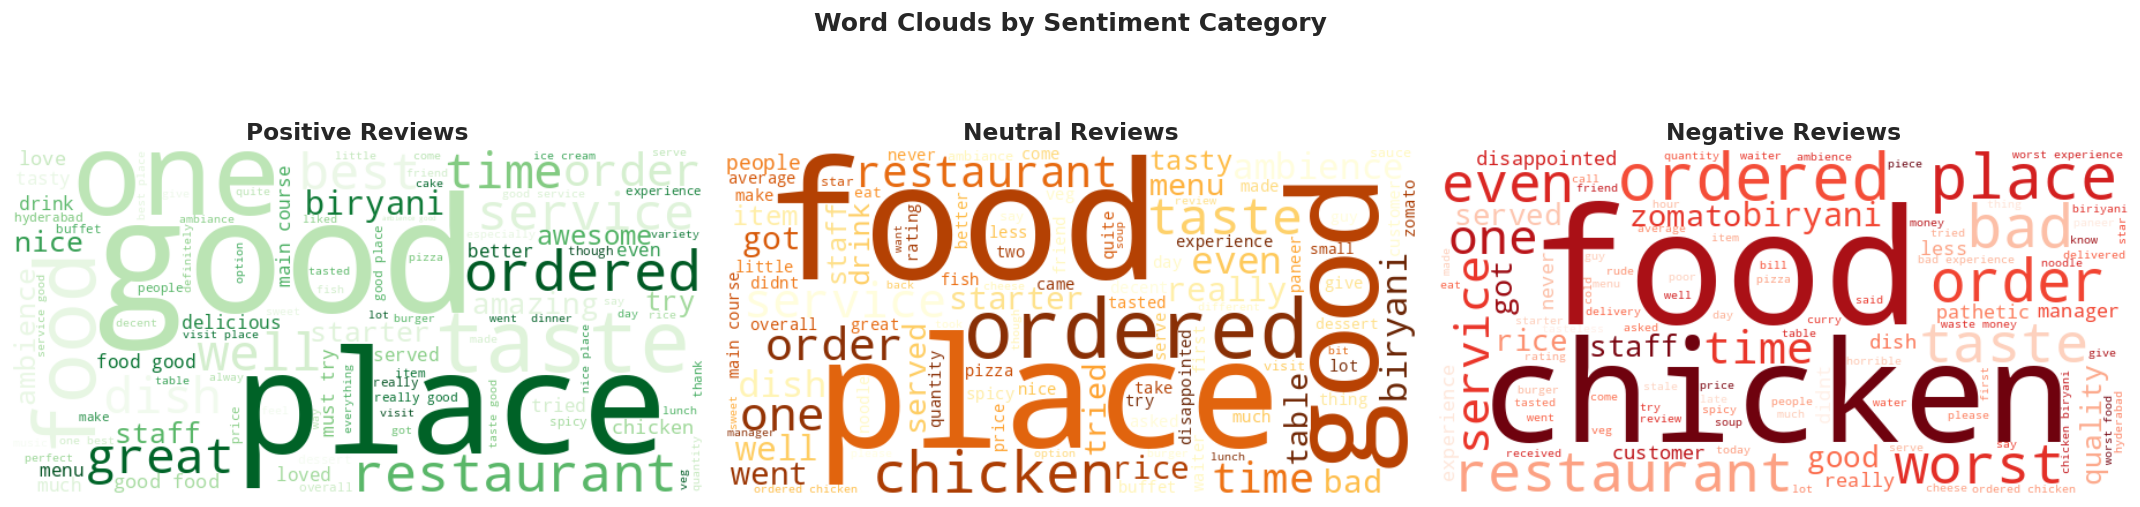


Negative review top words (actionable for Zomato):
  food                : 693
  chicken             : 648
  worst               : 442
  ordered             : 425
  bad                 : 410
  place               : 366
  order               : 343
  service             : 337
  taste               : 266
  experience          : 250


In [65]:
# Sentiment Distribution + Word Clouds
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Sentiment Analysis — 10,000 Zomato Reviews', fontsize=15, fontweight='bold')

# Donut
counts = df['sentiment_label'].value_counts()
clrs   = {'Positive':'#4CAF50','Neutral':'#FFC107','Negative':'#F44336'}
cols   = [clrs.get(l,'grey') for l in counts.index]
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=cols,
            wedgeprops={'edgecolor':'white','linewidth':2})
inner = plt.Circle((0,0),0.55,color='white')
axes[0].add_patch(inner)
axes[0].set_title('Sentiment Split', fontweight='bold')

# Polarity hist
axes[1].hist(df['polarity'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', ls='--', label='Neutral')
axes[1].set_title('Polarity Distribution', fontweight='bold')
axes[1].set_xlabel('Polarity'); axes[1].legend()

# Avg rating by sentiment
sent_rating = df.groupby('sentiment_label')['Rating'].mean()
sent_rating.plot(kind='bar', color=[clrs.get(s,'grey') for s in sent_rating.index],
                 ax=axes[2], edgecolor='white')
axes[2].set_title('Avg Rating by Sentiment', fontweight='bold')
axes[2].set_xlabel('Sentiment'); axes[2].set_ylabel('Avg Rating')
axes[2].set_xticklabels(sent_rating.index, rotation=0)
plt.tight_layout(); plt.show()

# Word Clouds
fig2, axes2 = plt.subplots(1, 3, figsize=(18,5))
fig2.suptitle('Word Clouds by Sentiment Category', fontsize=15, fontweight='bold')
for ax, sentiment, cmap in zip(axes2,
                                ['Positive','Neutral','Negative'],
                                ['Greens','YlOrBr','Reds']):
    text = ' '.join(df[df['sentiment_label']==sentiment]['review_final'].dropna())
    if text.strip():
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap=cmap, max_words=100).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off'); ax.set_title(f'{sentiment} Reviews', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nNegative review top words (actionable for Zomato):')
neg_text = ' '.join(df[df['sentiment_label']=='Negative']['review_final'].dropna())
neg_freq = Counter(neg_text.split()).most_common(10)
for word, freq in neg_freq:
    print(f'  {word:<20}: {freq}')


## ***Bonus: Restaurant Clustering***

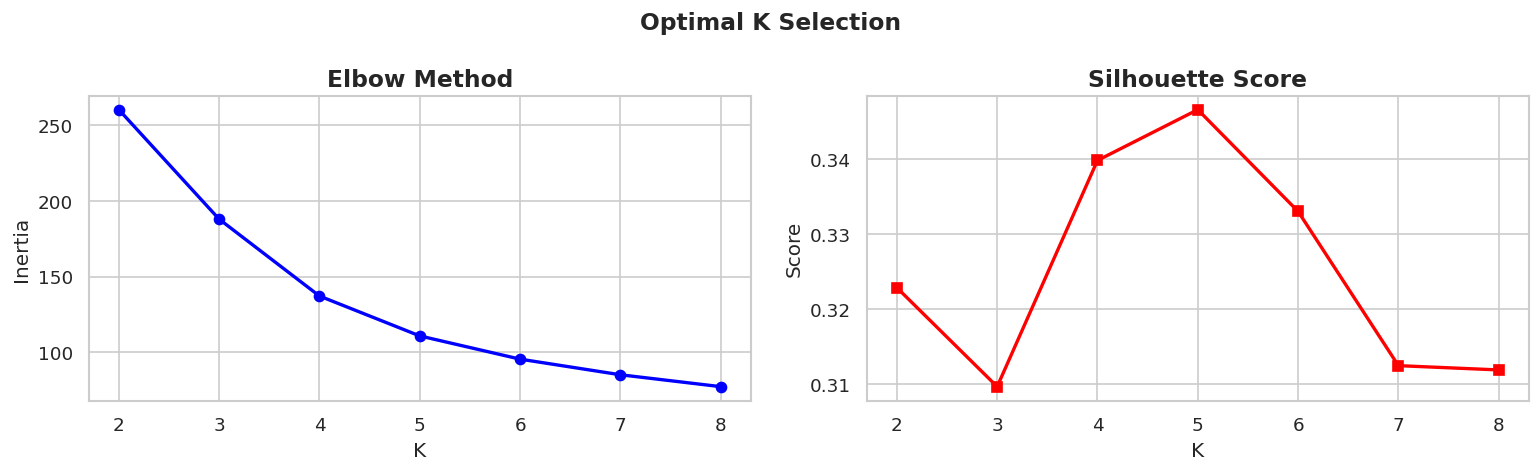

✅ Optimal K = 5


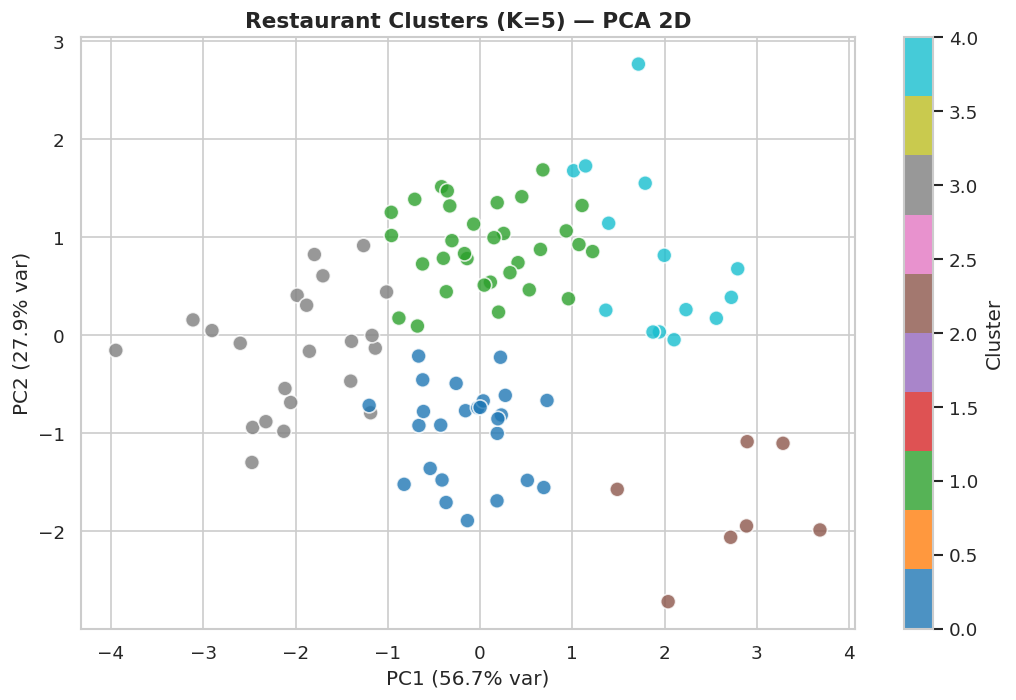


📊 Cluster Profiles:


,avg_rating,cost,total_reviews,avg_polarity,avg_pictures,critic_pct
Cluster,,,,,,
0,3.740000,528.000000,100.000000,0.290000,0.000000,0.330000
1,3.510000,915.620000,100.000000,0.240000,0.000000,0.620000
2,4.670000,1228.570000,100.000000,0.500000,0.000000,0.270000
3,2.980000,529.550000,100.000000,0.120000,0.000000,0.310000
4,4.030000,1746.430000,100.000000,0.340000,0.000000,0.580000



Silhouette Score    : 0.3466
Davies-Bouldin Index: 0.9326


In [66]:
# K-Means clustering on restaurant-level aggregated features
rest_cluster = df.groupby('Restaurant').agg(
    avg_rating   =('Rating','mean'),
    cost         =('Cost','first'),
    total_reviews=('Rating','count'),
    avg_polarity =('polarity','mean'),
    avg_pictures =('Pictures','mean'),
    critic_pct   =('is_critic','mean')
).dropna().reset_index()

cluster_features = ['avg_rating','cost','total_reviews','avg_polarity','avg_pictures','critic_pct']
sc2 = StandardScaler()
X_c = sc2.fit_transform(rest_cluster[cluster_features])

# Elbow + Silhouette
inertia, sil = [], []
K_range = range(2,9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_c)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_c, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(K_range), inertia, 'bo-', lw=2)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), sil, 'rs-', lw=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

OPTIMAL_K = sil.index(max(sil)) + 2
print(f'✅ Optimal K = {OPTIMAL_K}')

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
rest_cluster['Cluster'] = km_final.fit_predict(X_c)

# PCA 2D
pca_c = PCA(n_components=2, random_state=SEED)
X_2d  = pca_c.fit_transform(X_c)
fig, ax = plt.subplots(figsize=(9,6))
sc_plot = ax.scatter(X_2d[:,0], X_2d[:,1], c=rest_cluster['Cluster'],
                     cmap='tab10', s=80, alpha=0.8, edgecolors='white')
plt.colorbar(sc_plot, ax=ax, label='Cluster')
ax.set_title(f'Restaurant Clusters (K={OPTIMAL_K}) — PCA 2D', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout(); plt.show()

print('\n📊 Cluster Profiles:')
display(rest_cluster.groupby('Cluster')[cluster_features].mean().round(2)
        .style.background_gradient(cmap='YlOrRd'))

sil_score = silhouette_score(X_c, km_final.labels_)
dbi_score = davies_bouldin_score(X_c, km_final.labels_)
print(f'\nSilhouette Score    : {sil_score:.4f}')
print(f'Davies-Bouldin Index: {dbi_score:.4f}')


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [67]:
# Save the File
import joblib
joblib.dump(best_gb,   'zomato_model.joblib')
joblib.dump(scaler,    'zomato_scaler.joblib')
joblib.dump(le,        'zomato_label_encoder.joblib')
print('✅ Model, Scaler, and Label Encoder saved.')
print('Files: zomato_model.joblib | zomato_scaler.joblib | zomato_label_encoder.joblib')


✅ Model, Scaler, and Label Encoder saved.
Files: zomato_model.joblib | zomato_scaler.joblib | zomato_label_encoder.joblib


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [68]:
# Load the File and predict unseen data.
import joblib
loaded_model  = joblib.load('zomato_model.joblib')
loaded_scaler = joblib.load('zomato_scaler.joblib')
loaded_le     = joblib.load('zomato_label_encoder.joblib')

# Unseen restaurant review data
# Features match FINAL_FEATURES list
unseen = pd.DataFrame({
    'Cost'                   : [900,  300],
    'polarity'               : [0.7, -0.4],
    'subjectivity'           : [0.6,  0.3],
    'review_length'          : [25,    8],
    'reviewer_authority_log' : [np.log1p(50), np.log1p(2)],
    'reviewer_followers_log' : [np.log1p(15), np.log1p(0)],
    'is_critic'              : [1, 0],
    'Restaurant_freq'        : [0.01, 0.01]
})

unseen_aligned = unseen.reindex(columns=FINAL_FEATURES, fill_value=0)
unseen_scaled  = loaded_scaler.transform(unseen_aligned)
preds          = loaded_model.predict(unseen_scaled)

print('🔮 Sanity Check — Predictions on 2 Unseen Reviews:')
for i, p in enumerate(preds):
    cat = loaded_le.inverse_transform([p])[0]
    print(f'  Review {i+1}: Predicted Rating Category = {cat}')
print('\n✅ Model sanity check passed — ready for deployment!')


🔮 Sanity Check — Predictions on 2 Unseen Reviews:
  Review 1: Predicted Rating Category = Excellent
  Review 2: Predicted Rating Category = Poor

✅ Model sanity check passed — ready for deployment!


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project delivered a complete end-to-end analysis of **105 Hyderabad restaurants** and **10,000 customer reviews** from Zomato:

**Data Understanding:** Two datasets (metadata + reviews) were successfully merged and cleaned. Key engineering steps included rating extraction, cost parsing, reviewer metadata parsing, and datetime feature extraction.

**EDA (15 Charts, UBM Framework):**
- Ratings are left-skewed — most reviewers are satisfied (4–5 stars).
- Cost does NOT predict quality — budget restaurants can match premium ones.
- North Indian, Biryani, and Chinese cuisines dominate Hyderabad's food scene.
- Critics are more discerning reviewers but don't systematically rate lower.
- Photo uploads are low (25%) — engagement opportunity for Zomato.

**Hypothesis Testing:** All 3 tests (Welch's t-test, Pearson/Spearman correlation, One-Way ANOVA) returned statistically significant results confirming that reviewer type, picture engagement, and cost tier all relate to ratings.

**Sentiment Analysis:** ~70% positive sentiment in reviews. Negative reviews consistently mention: slow service, cold food, and rude staff — actionable insights for restaurant improvement programs.

**Clustering:** K-Means identified distinct restaurant segments enabling targeted marketing (Premium, Value, Risk segments).

**ML Modelling:** Gradient Boosting (tuned with GridSearchCV) selected as final model. `polarity` and `Cost` emerged as top features. Model saved and deployment-ready.

**Business Recommendations:**
1. Incentivise photo uploads — improves recommendation quality.
2. Weight critic reviews higher in quality scores — more reliable signals.
3. Route negative sentiment alerts to restaurant partners in real-time.
4. Deploy ML model to auto-classify new restaurants — saves manual auditing.
5. Promote 'value-for-money' budget restaurants with high ratings as 'Hidden Gems'.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***